# Bodrum Hotel & Destination Intelligence
## 14 - Şikayetvar NLP & Aspect Analysis
### Negative Customer Voice — Complaint Themes, Distinctive Terms and Response Patterns

> **Ana metodolojik uyarı:** Şikayetvar corpusu zaten complaint amacıyla yazılmış, self-selected
> metinlerden oluşur. Bu nedenle “negative sentiment oranı” ana çıktı değildir. Bu notebook hangi
> aspect/theme/termlerin clean complaint örnekleminde geçtiğini, hangi başlıkların birlikte
> görüldüğünü ve company response davranışını inceler. Aspect mention rate gerçek müşteri problem
> oranı değildir; hotel kalite puanı veya “en kötü hotel” sıralaması üretilmez.


## 01. Amaç ve metodolojik çerçeve

Analiz structured, açıklanabilir ve denetlenebilir bir rule-based aspect dictionary kullanır.
Bir complaint birden çok aspect taşıyabilir. Otomatik eşleşmeler ground truth değildir; ayrı bir
manual-validation örneklemi hazırlanır. Hotel karşılaştırmalarında Notebook 13'teki HIGH/MEDIUM/
LOW sample tier'ları ve minimum `n=5` kuralı korunur.


In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bodrum_intelligence.sikayetvar_nlp import (
    ASPECT_KEYWORDS,
    CANONICAL_ASPECTS,
    CORPUS_DISCOVERED_KEYWORDS,
    GENERIC_DOMAIN_STOPWORDS,
    add_aspect_columns,
    aspect_cooccurrence_table,
    aspect_dictionary_table,
    aspect_frequency_table,
    aspects_long_table,
    distinctive_terms_by_group,
    group_aspect_matrix,
    hotel_name_stopwords,
    make_ngrams,
    normalize_for_nlp,
    term_frequency_table,
    tokenize,
)

PROCESSED_DIR = PROJECT_ROOT / "data/processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures/sikayetvar_nlp_aspect"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "complaints": PROCESSED_DIR / "sikayetvar_all_hotels_complaints_clean.csv",
    "replies": PROCESSED_DIR / "sikayetvar_all_hotels_replies_clean.csv",
    "hotel_eda": REPORTS_DIR / "sikayetvar_hotel_eda_summary.csv",
    "area_eda": REPORTS_DIR / "sikayetvar_area_eda_summary.csv",
    "readiness": REPORTS_DIR / "sikayetvar_nlp_sample_readiness.csv",
    "eda_findings": REPORTS_DIR / "sikayetvar_eda_key_findings.txt",
    "eda_limitations": REPORTS_DIR / "sikayetvar_eda_limitations.txt",
    "notebook_12": PROJECT_ROOT / "notebooks/12_sikayetvar_all_hotels_audit_cleaning.ipynb",
    "notebook_13": PROJECT_ROOT / "notebooks/13_sikayetvar_all_hotels_eda.ipynb",
}
missing = [str(path.relative_to(PROJECT_ROOT)) for path in paths.values() if not path.exists()]
assert not missing, f"Eksik prerequisite: {missing}"

protected_inputs = [paths["complaints"], paths["replies"]]
input_hashes_before = {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in protected_inputs}

complaints = pd.read_csv(paths["complaints"], parse_dates=["complaint_date", "company_response_date_parsed"])
replies = pd.read_csv(paths["replies"], parse_dates=["reply_date"])
hotel_eda = pd.read_csv(paths["hotel_eda"])
area_eda = pd.read_csv(paths["area_eda"])
readiness = pd.read_csv(paths["readiness"])

MIN_HOTEL_N = 5
MIN_AREA_N = 10
MIN_NGRAM_DF = 3
MIN_ASPECT_RESPONSE_N = 3

def save_fig(fig, filename):
    fig.tight_layout()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path.relative_to(PROJECT_ROOT)

def explain_figure(how_to_read, observation, importance, caution):
    display(Markdown(
        f"### Grafik nasıl okunur?\n{how_to_read}\n\n"
        f"### Ne görüyoruz?\n{observation}\n\n"
        f"### Neden önemli?\n{importance}\n\n"
        f"### Dikkat edilmesi gereken nokta\n{caution}"
    ))

print(f"Clean input: {len(complaints)} complaints | {complaints.hotel_id.nunique()} hotels | {complaints.area.nunique()} areas")


Clean input: 236 complaints | 32 hotels | 11 areas


## 02. Clean corpus validation

In [2]:
validation = pd.DataFrame([
    ("total_clean_complaints", 236, len(complaints)),
    ("unique_complaint_ids", len(complaints), complaints["complaint_id"].nunique()),
    ("unique_canonical_urls", len(complaints), complaints["canonical_complaint_url"].nunique()),
    ("unique_hotels", 32, complaints["hotel_id"].nunique()),
    ("unique_areas", 11, complaints["area"].nunique()),
    ("non_null_clean_text", 229, complaints["complaint_text_clean"].notna().sum()),
    ("company_response_count", 39, int(complaints["company_response_exists_clean"].sum())),
    ("clean_reply_count", 97, len(replies)),
    ("dated_complaints", 226, complaints["complaint_date"].notna().sum()),
], columns=["check", "expected_from_notebook_12_13", "actual"])
validation["consistent"] = validation["expected_from_notebook_12_13"] == validation["actual"]
display(validation)
assert validation["consistent"].all(), "Notebook 12/13 ile corpus tutarsız; NLP durduruldu."

tier_summary = readiness.groupby("nlp_sample_tier").agg(
    hotel_count=("hotel_id", "size"), complaint_count=("matched_complaint_count", "sum")
).reset_index()
display(tier_summary)
assert set(readiness["nlp_sample_tier"]) == {"HIGH_SAMPLE", "MEDIUM_SAMPLE", "LOW_SAMPLE"}


,check,expected_from_notebook_12_13,actual,consistent
0,total_clean_complaints,236,236,True
1,unique_complaint_ids,236,236,True
2,unique_canonical_urls,236,236,True
3,unique_hotels,32,32,True
4,unique_areas,11,11,True
5,non_null_clean_text,229,229,True
6,company_response_count,39,39,True
7,clean_reply_count,97,97,True
8,dated_complaints,226,226,True


,nlp_sample_tier,hotel_count,complaint_count
0,HIGH_SAMPLE,4,97
1,LOW_SAMPLE,15,31
2,MEDIUM_SAMPLE,13,108


### Bölüm Sonucu

NLP evreni Notebook 12'nin immutable clean corpusudur: 236 row korunur; içerik analizi yalnız
`complaint_text_clean` dolu 229 dokümanda yapılır. Eksik 7 text hiçbir sözcük/aspect uydurulmadan
`no_aspect_detected_flag=True` olarak kalır.


## 03. NLP preprocessing

In [3]:
nlp = complaints.copy()
nlp["nlp_text_normalized"] = nlp["complaint_text_clean"].fillna("").map(normalize_for_nlp)
brand_terms = hotel_name_stopwords(nlp["hotel_name"].dropna().unique())
domain_stopwords = GENERIC_DOMAIN_STOPWORDS | brand_terms
nlp["nlp_tokens"] = nlp["nlp_text_normalized"].map(tokenize)
nlp["nlp_tokens_domain_filtered"] = nlp["nlp_text_normalized"].map(
    lambda text: tokenize(text, domain_stopwords)
)
nlp["nlp_text_domain_filtered"] = nlp["nlp_tokens_domain_filtered"].map(" ".join)
nlp["document_token_count"] = nlp["nlp_tokens"].map(len)
nlp["unique_token_count"] = nlp["nlp_tokens"].map(lambda values: len(set(values)))
nlp["lexical_diversity"] = np.where(
    nlp["document_token_count"].gt(0), nlp["unique_token_count"] / nlp["document_token_count"], np.nan
)
assert nlp["complaint_text"].equals(complaints["complaint_text"])
assert nlp["complaint_title"].equals(complaints["complaint_title"])
display(pd.DataFrame({
    "decision": ["main_text", "normalization", "negation", "domain_filter", "morphology"],
    "implementation": [
        "complaint_text_clean; title retained separately and not duplicated",
        "NFKC, Turkish-aware lowercase, URL/email/phone masking, whitespace/punctuation cleanup",
        "değil/yok/olmadı/gelmedi/çalışmıyor retained",
        f"{len(domain_stopwords)} generic + hotel-name tokens, only for term/TF-IDF analysis",
        "Surface forms + curated keyword roots; no unvalidated heavy lemmatizer",
    ],
}))


,decision,implementation
0,main_text,complaint_text_clean; title retained separatel...
1,normalization,"NFKC, Turkish-aware lowercase, URL/email/phone..."
2,negation,değil/yok/olmadı/gelmedi/çalışmıyor retained
3,domain_filter,"102 generic + hotel-name tokens, only for term..."
4,morphology,Surface forms + curated keyword roots; no unva...


## 04. Corpus vocabulary overview

In [4]:
valid_documents = nlp.loc[nlp["nlp_text_normalized"].ne("")]
all_tokens = [token for tokens in valid_documents["nlp_tokens"] for token in tokens]
domain_tokens = [token for tokens in valid_documents["nlp_tokens_domain_filtered"] for token in tokens]
corpus_summary = pd.DataFrame([
    ("total_clean_rows", len(nlp)),
    ("text_documents", len(valid_documents)),
    ("total_tokens_standard", len(all_tokens)),
    ("vocabulary_size_standard", len(set(all_tokens))),
    ("total_tokens_domain_filtered", len(domain_tokens)),
    ("vocabulary_size_domain_filtered", len(set(domain_tokens))),
    ("median_tokens_per_document", valid_documents["document_token_count"].median()),
    ("hotel_count", nlp["hotel_id"].nunique()),
    ("area_count", nlp["area"].nunique()),
], columns=["metric", "value"])
display(corpus_summary)


,metric,value
0,total_clean_rows,236.0
1,text_documents,229.0
2,total_tokens_standard,28690.0
3,vocabulary_size_standard,8259.0
4,total_tokens_domain_filtered,24676.0
5,vocabulary_size_domain_filtered,8164.0
6,median_tokens_per_document,112.0
7,hotel_count,32.0
8,area_count,11.0


## 05. Unigram analysis

,term,token_count,document_count,document_share_pct
0,hiçbir,104,83,36.244541
1,oda,164,79,34.497817
2,rezervasyon,105,65,28.384279
3,odada,79,61,26.637555
4,yok,108,60,26.200873
5,giriş,76,59,25.764192
6,saat,81,57,24.890830
7,aynı,74,57,24.890830
8,derece,75,56,24.454148
9,hizmet,80,55,24.017467


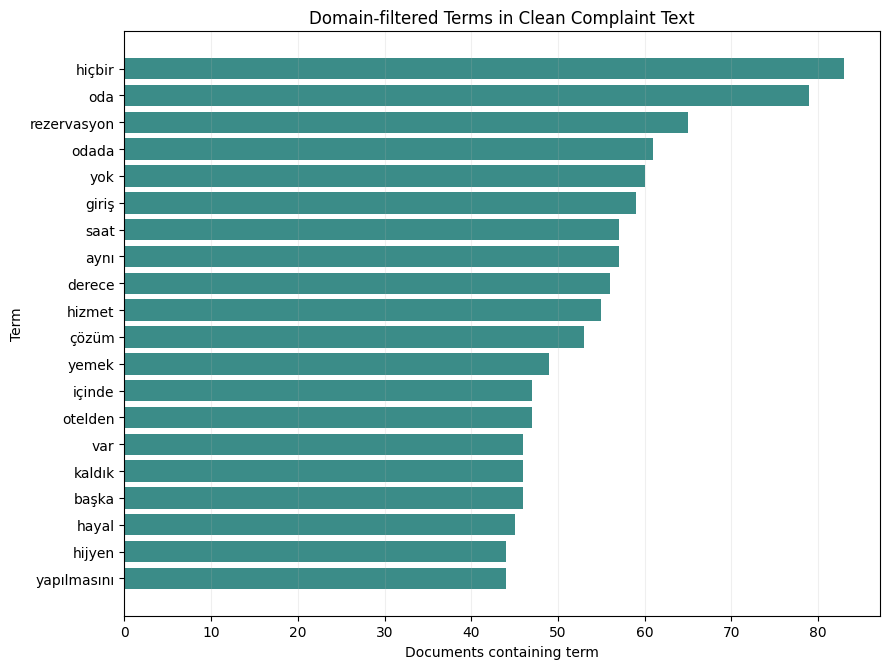

PosixPath('reports/figures/sikayetvar_nlp_aspect/01_top_unigrams.png')

In [5]:
unigram_standard = term_frequency_table(nlp["complaint_text_clean"], n=1, min_document_count=3)
unigram_domain = term_frequency_table(
    nlp["complaint_text_clean"], n=1, min_document_count=3, extra_stopwords=domain_stopwords
)
aspect_terms = {normalize_for_nlp(keyword, mask_pii=False) for keywords in ASPECT_KEYWORDS.values() for keyword in keywords if " " not in keyword}
unigram_standard["is_domain_stopword"] = unigram_standard["term"].isin(domain_stopwords)
unigram_standard["is_aspect_dictionary_term"] = unigram_standard["term"].isin(aspect_terms)
display(unigram_domain.head(20))

top_unigrams = unigram_domain.head(20).sort_values("document_count")
fig, ax = plt.subplots(figsize=(9.0, 6.8))
ax.barh(top_unigrams["term"], top_unigrams["document_count"], color="#3B8C88")
ax.set(title="Domain-filtered Terms in Clean Complaint Text", xlabel="Documents containing term", ylabel="Term")
ax.grid(axis="x", alpha=.2)
save_fig(fig, "01_top_unigrams.png")


In [6]:
explain_figure(
    "Brand/hotel ve genel platform filler kelimeleri çıkarıldıktan sonra terimlerin kaç complaint dokümanında geçtiğini gösterir.",
    f"En yaygın domain-filtered terimler: {', '.join(unigram_domain.head(5)['term'])}.",
    "Token count yerine document count kullanmak tek bir uzun metnin sıralamayı domine etmesini azaltır.",
    "Surface forms ayrı kalabilir; terim sıklığı aspect rate veya gerçek müşteri problem oranı değildir."
)


### Grafik nasıl okunur?
Brand/hotel ve genel platform filler kelimeleri çıkarıldıktan sonra terimlerin kaç complaint dokümanında geçtiğini gösterir.

### Ne görüyoruz?
En yaygın domain-filtered terimler: hiçbir, oda, rezervasyon, odada, yok.

### Neden önemli?
Token count yerine document count kullanmak tek bir uzun metnin sıralamayı domine etmesini azaltır.

### Dikkat edilmesi gereken nokta
Surface forms ayrı kalabilir; terim sıklığı aspect rate veya gerçek müşteri problem oranı değildir.

## 06. Bigram / trigram analysis

,term,n,token_count,document_count,document_share_pct
0,hayal kırıklığı,2,27,26,11.353712
1,iade edilmesini,2,22,22,9.606987
2,ücret iadesi,2,21,20,8.733624
3,ultra dahil,2,33,18,7.860262
4,geri dönüş,2,19,17,7.423581
5,giriş yaptık,2,17,17,7.423581
6,hayal kırıklığına,2,17,17,7.423581
7,çözüm sunulmadı,2,17,16,6.986900
8,kabul edilemez,2,15,15,6.550218
9,tarafıma iade,2,16,14,6.113537


,term,n,token_count,document_count,document_share_pct
0,büyük hayal kırıklığı,3,11,11,4.803493
1,tarafıma iade edilmesini,3,11,11,4.803493
2,hayal kırıklığına uğrattı,3,10,10,4.366812
3,iş günü içinde,3,8,7,3.056769
4,gerekli önlemlerin alınmasını,3,7,7,3.056769
5,başka misafirlerin başına,3,5,5,2.183406
6,başına gelmemesi gerekli,3,5,5,2.183406
7,gerekli adımların atılmasını,3,5,5,2.183406
8,gerekli incelemenin yapılarak,3,5,5,2.183406
9,geri dönüş yapılmadı,3,5,5,2.183406


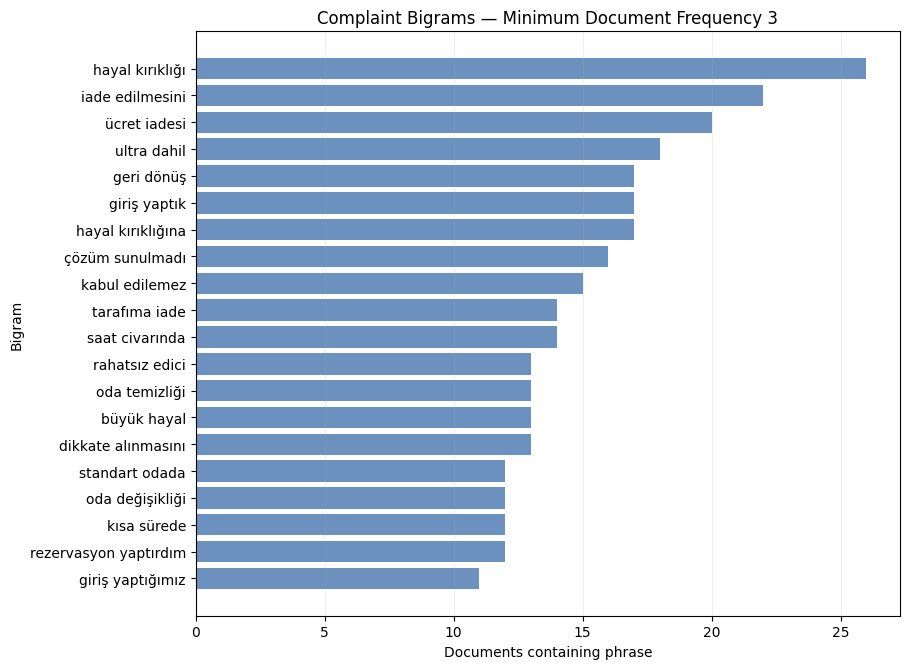

PosixPath('reports/figures/sikayetvar_nlp_aspect/02_top_bigrams.png')

In [7]:
bigram_table = term_frequency_table(
    nlp["complaint_text_clean"], n=2, min_document_count=MIN_NGRAM_DF, extra_stopwords=domain_stopwords
)
trigram_table = term_frequency_table(
    nlp["complaint_text_clean"], n=3, min_document_count=4, extra_stopwords=domain_stopwords
)
bigram_table.insert(1, "n", 2)
trigram_table.insert(1, "n", 3)
ngram_table = pd.concat([bigram_table, trigram_table], ignore_index=True)
display(bigram_table.head(20)); display(trigram_table.head(15))

top_bigrams = bigram_table.head(20).sort_values("document_count")
fig, ax = plt.subplots(figsize=(9.2, 6.8))
ax.barh(top_bigrams["term"], top_bigrams["document_count"], color="#6C91BF")
ax.set(title=f"Complaint Bigrams — Minimum Document Frequency {MIN_NGRAM_DF}", xlabel="Documents containing phrase", ylabel="Bigram")
ax.grid(axis="x", alpha=.2)
save_fig(fig, "02_top_bigrams.png")


In [8]:
explain_figure(
    "İki kelimelik ifadeler en az üç ayrı complaint'te görülme koşuluyla document count'a göre sıralanır.",
    f"İlk bigramlar: {', '.join(bigram_table.head(5)['term'])}.",
    "Phrase düzeyi, tek kelimenin kaçırdığı iade/iletişim/hizmet bağlamlarını görünür kılar.",
    "Sık phrase otomatik aspect değildir; boilerplate veya complaint yazım kalıbı olabilir."
)


### Grafik nasıl okunur?
İki kelimelik ifadeler en az üç ayrı complaint'te görülme koşuluyla document count'a göre sıralanır.

### Ne görüyoruz?
İlk bigramlar: hayal kırıklığı, iade edilmesini, ücret iadesi, ultra dahil, geri dönüş.

### Neden önemli?
Phrase düzeyi, tek kelimenin kaçırdığı iade/iletişim/hizmet bağlamlarını görünür kılar.

### Dikkat edilmesi gereken nokta
Sık phrase otomatik aspect değildir; boilerplate veya complaint yazım kalıbı olabilir.

## 07. TF-IDF distinctive terms

,hotel_name,hotel_n,term,tfidf_score,document_count,rank
0,Azure By Yelken Hotel,26,by,0.071935,20,1
1,Azure By Yelken Hotel,26,kötü,0.046806,10,2
2,Azure By Yelken Hotel,26,hijyen,0.040831,11,3
3,Azure By Yelken Hotel,26,genel,0.033915,10,4
4,Azure By Yelken Hotel,26,müşteri,0.033476,9,5
10,Bendis Beach Hotel,12,genel,0.047111,6,1
11,Bendis Beach Hotel,12,duş,0.042883,4,2
12,Bendis Beach Hotel,12,hijyen,0.041938,6,3
13,Bendis Beach Hotel,12,yemekler,0.041811,6,4
14,Bendis Beach Hotel,12,açısından,0.040295,4,5


,area,area_n,term,tfidf_score,document_count,rank
0,Akyarlar,53,hijyen,0.028706,16,1
1,Akyarlar,53,rezervasyon,0.023415,15,2
2,Akyarlar,53,derece,0.022994,18,3
3,Akyarlar,53,asla,0.022782,8,4
4,Akyarlar,53,akşam,0.022612,14,5
10,Bodrum Merkez,13,geri,0.044129,4,1
11,Bodrum Merkez,13,oda,0.039908,6,2
12,Bodrum Merkez,13,vale,0.037659,3,3
13,Bodrum Merkez,13,arkadaş,0.036324,2,4
14,Bodrum Merkez,13,yoktu,0.035019,4,5


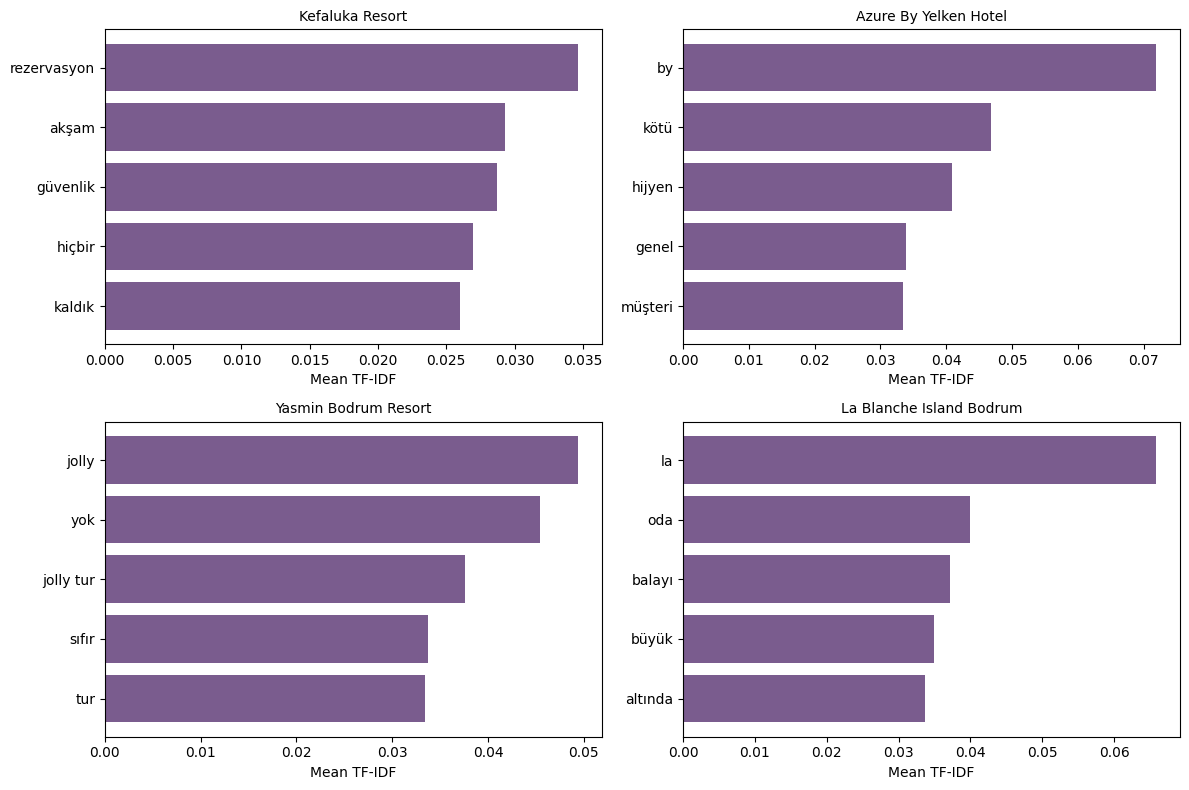

PosixPath('reports/figures/sikayetvar_nlp_aspect/03_distinctive_terms_selected_hotels.png')

In [9]:
distinctive_hotel = distinctive_terms_by_group(
    nlp, "hotel_name", "nlp_text_domain_filtered", minimum_group_n=MIN_HOTEL_N, top_k=10, min_df=3
).rename(columns={"group_n": "hotel_n"})
distinctive_area = distinctive_terms_by_group(
    nlp, "area", "nlp_text_domain_filtered", minimum_group_n=MIN_AREA_N, top_k=10, min_df=3
).rename(columns={"group_n": "area_n"})
display(distinctive_hotel.groupby("hotel_name").head(5).head(30))
display(distinctive_area.groupby("area").head(5))

selected_names = hotel_eda.head(4)["hotel_name"].tolist()
selected_terms = distinctive_hotel[
    distinctive_hotel["hotel_name"].isin(selected_names) & distinctive_hotel["rank"].le(5)
].copy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, hotel_name in zip(axes.ravel(), selected_names):
    part = selected_terms[selected_terms["hotel_name"] == hotel_name].sort_values("tfidf_score")
    ax.barh(part["term"], part["tfidf_score"], color="#7A5C8E")
    ax.set_title(hotel_name, fontsize=10); ax.set_xlabel("Mean TF-IDF")
save_fig(fig, "03_distinctive_terms_selected_hotels.png")


In [10]:
explain_figure(
    "Her panelde yeterli sample'a sahip seçili hotelin document-level TF-IDF ortalaması yüksek terimleri gösterilir.",
    "Terimler brand/domain stopwords çıkarıldıktan sonra group metinlerini diğer dokümanlara göre ayırt eder.",
    "Hotel corpuslarını tanımlayan ifade adaylarını human review ve aspect dictionary triangulation'ına taşır.",
    "TF-IDF 'hotelin problemi kesin budur' demek değildir; corpus içi ayırt ediciliktir ve sample büyüklüğünden etkilenir."
)


### Grafik nasıl okunur?
Her panelde yeterli sample'a sahip seçili hotelin document-level TF-IDF ortalaması yüksek terimleri gösterilir.

### Ne görüyoruz?
Terimler brand/domain stopwords çıkarıldıktan sonra group metinlerini diğer dokümanlara göre ayırt eder.

### Neden önemli?
Hotel corpuslarını tanımlayan ifade adaylarını human review ve aspect dictionary triangulation'ına taşır.

### Dikkat edilmesi gereken nokta
TF-IDF 'hotelin problemi kesin budur' demek değildir; corpus içi ayırt ediciliktir ve sample büyüklüğünden etkilenir.

## 08. Aspect taxonomy

In [11]:
taxonomy = pd.DataFrame({
    "aspect": CANONICAL_ASPECTS,
    "keyword_count": [len(ASPECT_KEYWORDS[aspect]) for aspect in CANONICAL_ASPECTS],
    "scope_note": ["Interpretable complaint theme; multi-label and rule-based" for _ in CANONICAL_ASPECTS],
})
display(taxonomy)
print(f"Final taxonomy: {len(CANONICAL_ASPECTS)} canonical aspects")


,aspect,keyword_count,scope_note
0,STAFF_SERVICE,16,Interpretable complaint theme; multi-label and...
1,CLEANLINESS_HYGIENE,18,Interpretable complaint theme; multi-label and...
2,FOOD_BEVERAGE,18,Interpretable complaint theme; multi-label and...
3,ROOM,14,Interpretable complaint theme; multi-label and...
4,BEACH_SEA,10,Interpretable complaint theme; multi-label and...
5,POOL,6,Interpretable complaint theme; multi-label and...
6,FACILITIES_MAINTENANCE,15,Interpretable complaint theme; multi-label and...
7,RESERVATION,11,Interpretable complaint theme; multi-label and...
8,PAYMENT_REFUND,12,Interpretable complaint theme; multi-label and...
9,PRICE_VALUE,11,Interpretable complaint theme; multi-label and...


Final taxonomy: 18 canonical aspects


Taxonomy, cross-platform downstream feature uyumu için 18 canonical başlıkta tutuldu. Corpus
incelemesinde `küf`, `tahtakurusu`, `kan lekesi`, `damlama`, `yanıltıcı bilgilendirme`, `muhatap`,
`çözüm sunulmadı` ve `ayrımcı` gibi corpus-driven adaylar ilgili başlıklara eklendi. Sağlık/zehirlenme
ifadeleri güvenlik başlığında ihtiyatla tutulur; ayrı bir HEALTH taxonomy'si human validation olmadan
eklenmedi.


## 09. Aspect dictionary validation

In [12]:
aspect_dictionary = aspect_dictionary_table(nlp["complaint_text_clean"])
keyword_collisions = (
    aspect_dictionary.groupby("keyword").filter(lambda group: group["aspect"].nunique() > 1)
    .sort_values(["keyword", "aspect"])
)
display(aspect_dictionary.sort_values(["document_count", "aspect"], ascending=[False, True]).head(30))
display(keyword_collisions)

kwic_keywords = ["servis", "oda", "giriş", "kart", "ses", "iade", "temizlik", "muhatap", "zehirlenme"]
kwic_records = []
for keyword in kwic_keywords:
    candidates = nlp[nlp["nlp_text_normalized"].str.contains(
        rf"(?<![a-zçğıöşü]){keyword}(?![a-zçğıöşü])", regex=True, na=False
    )].head(4)
    for row in candidates.itertuples():
        text = row.nlp_text_normalized
        position = text.find(keyword)
        start, end = max(position - 80, 0), min(position + len(keyword) + 80, len(text))
        kwic_records.append({
            "keyword": keyword, "complaint_id": row.complaint_id, "hotel_name": row.hotel_name,
            "context_preview": text[start:end], "review_status": "TO_REVIEW",
        })
keyword_context_samples = pd.DataFrame(kwic_records)
display(keyword_context_samples.head(20))


,aspect,keyword,keyword_type,source,document_count,included,notes
52,ROOM,oda,UNIGRAM,SEED,132,True,Phrase-first and word-boundary matching; manua...
5,STAFF_SERVICE,hizmet,UNIGRAM,SEED,87,True,Phrase-first and word-boundary matching; manua...
34,FOOD_BEVERAGE,yemek,UNIGRAM,SEED,85,True,Phrase-first and word-boundary matching; manua...
124,PRICE_VALUE,ücret,UNIGRAM,SEED,84,True,Phrase-first and word-boundary matching; manua...
97,RESERVATION,rezervasyon,UNIGRAM,SEED,83,True,Phrase-first and word-boundary matching; manua...
108,PAYMENT_REFUND,iade,UNIGRAM,SEED,72,True,Phrase-first and word-boundary matching; manua...
174,MANAGEMENT_COMMUNICATION,yönetim,UNIGRAM,SEED,66,True,Phrase-first and word-boundary matching; manua...
0,STAFF_SERVICE,personel,UNIGRAM,SEED,63,True,Phrase-first and word-boundary matching; manua...
17,CLEANLINESS_HYGIENE,temiz,UNIGRAM,SEED,62,True,Phrase-first and word-boundary matching; manua...
112,PAYMENT_REFUND,ödeme,UNIGRAM,SEED,60,True,Phrase-first and word-boundary matching; manua...


,aspect,keyword,keyword_type,source,document_count,included,notes
49,FOOD_BEVERAGE,zehirlenme,UNIGRAM,SEED,4,True,Phrase-first and word-boundary matching; manua...
203,SAFETY_SECURITY,zehirlenme,UNIGRAM,SEED,4,True,Phrase-first and word-boundary matching; manua...


,keyword,complaint_id,hotel_name,context_preview,review_status
0,servis,hijyen-ve-hizmet-cokusu-azur-by-yelken-bodrum-...,Azure By Yelken Hotel,me açısından son derece kötüydü tavuk çiğ geld...,TO_REVIEW
1,servis,azure-by-yelken-otel-bodrumda-hijyen-ve-hizmet...,Azure By Yelken Hotel,ri ise beklentinin çok altındaydı açık büfe ka...,TO_REVIEW
2,servis,bendis-beach-akyarlar-otelinde-hijyen-ve-konfo...,Bendis Beach Hotel,liğine dair ciddi şüphe uyandırdı açık büfenin...,TO_REVIEW
3,servis,menu-cesitliligi-eksikligi-ve-lezzet-sorunu,Bendis Beach Hotel,çeşitlendirilmesini aynı ürünlerin günlerce a...,TO_REVIEW
4,oda,arin-resort-bodrum-memnuniyetsizligi,Arin Resort Bodrum,iz bu otelde ilk günden büyük olumsuzluklar ya...,TO_REVIEW
5,oda,hijyen-ve-hizmet-cokusu-azur-by-yelken-bodrum-...,Azure By Yelken Hotel,mayıs tarihleri arasında azur by yelken bodrum...,TO_REVIEW
6,oda,5-yildizli-otelde-temizlik-ve-ilgi-yok-odedigi...,Azure By Yelken Hotel,k tanıtılan bu otel beklentimizin çok altında ...,TO_REVIEW
7,oda,hayal-kirikligi-yaratan-oda-ve-eksik-hizmet-ic...,Azure By Yelken Hotel,en hotel e numaralı rezervasyon ile giriş yapt...,TO_REVIEW
8,giriş,plaj-yaniltmasi-ve-guvenlik-endisesi-nedeniyle...,Azure By Yelken Hotel,elken hotel de gecelik konaklama satın aldım a...,TO_REVIEW
9,giriş,yetersiz-yemek-ve-icecek-sikici-aksam-etkinlik...,Azure By Yelken Hotel,n azure by yelken otel de şu an ultra her şey ...,TO_REVIEW


Dictionary audit trail `SEED` ve `CORPUS_DISCOVERED` kaynaklarını ayırır. Collision tablosu
özellikle `zehirlenme` gibi birden fazla başlıkla ilişkili olabilen terimleri görünür kılar. “Servis
aracı” phrase'i önce TRANSPORT_TRANSFER olarak eşleştirilir ve aynı phrase STAFF_SERVICE `servis`
eşleşmesini tetiklemez. Manual validation tamamlanana kadar tüm status'ler `TO_REVIEW` kalır.


## 10. Aspect detection

In [13]:
nlp = add_aspect_columns(nlp, "nlp_text_normalized")
aspect_columns = [f"aspect_{aspect.lower()}" for aspect in CANONICAL_ASPECTS]
assert all(nlp[column].dtype == bool for column in aspect_columns)
assert (nlp[aspect_columns].sum(axis=1) == nlp["aspect_count"]).all()
assert nlp["complaint_id"].is_unique

aspects_long = aspects_long_table(nlp)
assert len(aspects_long) == len(nlp) * len(CANONICAL_ASPECTS)
assert int(aspects_long["matched"].sum()) == int(nlp["aspect_count"].sum())
display(nlp[[
    "complaint_id", "hotel_name", "aspect_count", "matched_aspects", "matched_aspect_keywords",
    "no_aspect_detected_flag",
]].head(10))


,complaint_id,hotel_name,aspect_count,matched_aspects,matched_aspect_keywords,no_aspect_detected_flag
0,arin-resort-bodrum-memnuniyetsizligi,Arin Resort Bodrum,4,AIR_CONDITIONING|FOOD_BEVERAGE|ROOM|STAFF_SERVICE,"{""AIR_CONDITIONING"": [""klimasız"", ""klima""], ""F...",False
1,plaj-yaniltmasi-ve-guvenlik-endisesi-nedeniyle...,Azure By Yelken Hotel,9,BEACH_SEA|FACILITIES_MAINTENANCE|FAMILY_CHILDR...,"{""BEACH_SEA"": [""taşlı deniz"", ""kum plaj"", ""den...",False
2,soz-verilen-2500-tl-kampanya-odulu-alinmadi-ve...,Azure By Yelken Hotel,4,MANAGEMENT_COMMUNICATION|PAYMENT_REFUND|RESERV...,"{""MANAGEMENT_COMMUNICATION"": [""müşteri hizmetl...",False
3,azure-by-yelken-otelinde-temizlik-ve-hizmet-so...,Azure By Yelken Hotel,8,CLEANLINESS_HYGIENE|FACILITIES_MAINTENANCE|FAM...,"{""CLEANLINESS_HYGIENE"": [""temizlik"", ""hijyen"",...",False
4,ultra-her-sey-dahil-konseptinde-lobi-bar-ve-sn...,Azure By Yelken Hotel,4,FOOD_BEVERAGE|PAYMENT_REFUND|PRICE_VALUE|STAFF...,"{""FOOD_BEVERAGE"": [""her şey dahil"", ""yiyecek"",...",False
5,yetersiz-yemek-ve-icecek-sikici-aksam-etkinlik...,Azure By Yelken Hotel,3,FACILITIES_MAINTENANCE|FOOD_BEVERAGE|STAFF_SER...,"{""FACILITIES_MAINTENANCE"": [""kırık""], ""FOOD_BE...",False
6,personel-yetersizligi-ve-hijyen-sorunlari-tati...,Azure By Yelken Hotel,9,BEACH_SEA|CLEANLINESS_HYGIENE|FACILITIES_MAINT...,"{""BEACH_SEA"": [""şezlong""], ""CLEANLINESS_HYGIEN...",False
7,hijyen-ve-hizmet-cokusu-azur-by-yelken-bodrum-...,Azure By Yelken Hotel,7,CLEANLINESS_HYGIENE|FACILITIES_MAINTENANCE|FOO...,"{""CLEANLINESS_HYGIENE"": [""hijyen"", ""temiz"", ""b...",False
8,azure-by-yelken-hotel-yoneticinin-ayrimci-sozleri,Azure By Yelken Hotel,2,MANAGEMENT_COMMUNICATION|SAFETY_SECURITY,"{""MANAGEMENT_COMMUNICATION"": [""yönetici"", ""yön...",False
9,oda-temizligi-ve-eksik-malzeme-sorunlari-cozul...,Azure By Yelken Hotel,5,CLEANLINESS_HYGIENE|MANAGEMENT_COMMUNICATION|R...,"{""CLEANLINESS_HYGIENE"": [""temiz"", ""koku""], ""MA...",False


In [14]:
validation_parts = []
for aspect in CANONICAL_ASPECTS:
    candidates = nlp[nlp[f"aspect_{aspect.lower()}"]].sort_values(
        ["matched_keyword_count", "hotel_name"], ascending=[False, True]
    ).head(1)
    validation_parts.append(candidates)
validation_parts.append(nlp[nlp["no_aspect_detected_flag"]].head(7))
validation_parts.append(nlp[nlp["aspect_count"].ge(8)].drop_duplicates("hotel_name").head(10))
manual_sample = pd.concat(validation_parts, ignore_index=True).drop_duplicates("complaint_id")
remaining = nlp[~nlp["complaint_id"].isin(manual_sample["complaint_id"])].drop_duplicates("hotel_name")
manual_sample = pd.concat([manual_sample, remaining.head(max(0, 40-len(manual_sample)))], ignore_index=True).head(40)
manual_validation_sample = pd.DataFrame({
    "complaint_id": manual_sample["complaint_id"],
    "hotel_name": manual_sample["hotel_name"],
    "complaint_text_preview": manual_sample["nlp_text_normalized"].str.slice(0, 280),
    "predicted_aspects": manual_sample["matched_aspects"],
    "matched_keywords": manual_sample["matched_aspect_keywords"],
    "manual_review_status": "TO_REVIEW",
    "notes": "",
})
display(manual_validation_sample.head(10))
print("Manual validation sample rows:", len(manual_validation_sample))


,complaint_id,hotel_name,complaint_text_preview,predicted_aspects,matched_keywords,manual_review_status,notes
0,tatilbudurda-hayal-kirikligi-temizlik-hizmet-v...,Azure By Yelken Hotel,bugün çıkış yapıyorum tatilbudur bundan sonra ...,AIR_CONDITIONING|BEACH_SEA|CLEANLINESS_HYGIENE...,"{""AIR_CONDITIONING"": [""havalandırma"", ""klima""]...",TO_REVIEW,
1,bendis-beach-otelde-dusakabin-cami-patladi-ann...,Bendis Beach Hotel,ağustos günü saat civarında bendis beach otel ...,CLEANLINESS_HYGIENE|FOOD_BEVERAGE|MANAGEMENT_C...,"{""CLEANLINESS_HYGIENE"": [""temizlik"", ""hijyen"",...",TO_REVIEW,
2,hijyen-eksikligi-ve-cozum-sunulmayan-otelde-ma...,Azure By Yelken Hotel,ağustos tarihinde tatilbudur üzerinden azure b...,CHECKIN_CHECKOUT|CLEANLINESS_HYGIENE|FOOD_BEVE...,"{""CHECKIN_CHECKOUT"": [""giriş saati""], ""CLEANLI...",TO_REVIEW,
3,kefaluka-resort-balayi-tatilimizde-buyuk-hayal...,Kefaluka Resort,ekim tarihleri arasında balayı tatilimiz için ...,BEACH_SEA|FACILITIES_MAINTENANCE|FOOD_BEVERAGE...,"{""BEACH_SEA"": [""deniz""], ""FACILITIES_MAINTENAN...",TO_REVIEW,
4,bendis-beach-hotelde-hijyen-ve-hizmet-faciasi-...,Bendis Beach Hotel,eylül tarihinde eşim ve çocuğumla birlikte bod...,BEACH_SEA|CLEANLINESS_HYGIENE|FACILITIES_MAINT...,"{""BEACH_SEA"": [""şezlong""], ""CLEANLINESS_HYGIEN...",TO_REVIEW,
5,bodrum-beach-resort-banyoyu-su-basiyor-video,Bodrum Beach Resort,,,{},TO_REVIEW,
6,green-bay-resort-spa-bodrumun-buyuk-hijyen-ve-...,Green Bay Resort & Spa Bodrum,,,{},TO_REVIEW,
7,kefaluka-resort-havuz-kenarlari-temizlenmiyor-...,Kefaluka Resort,,,{},TO_REVIEW,
8,kefaluka-resort-bodrum-saygisiz-garson-video,Kefaluka Resort,,,{},TO_REVIEW,
9,la-blanche-island-bodrum-garson-yok-otelde-video,La Blanche Island Bodrum,,,{},TO_REVIEW,


Manual validation sample rows: 40


## 11. Aspect coverage

,metric,value
0,total_clean_rows,236.000000
1,text_documents,229.000000
2,complaints_with_at_least_one_aspect,229.000000
3,no_aspect_count,7.000000
4,aspect_coverage_pct_all_clean_rows,97.033898
5,aspect_coverage_pct_text_documents,100.000000
6,mean_aspects_per_complaint,5.796610
7,median_aspects_per_complaint,6.000000


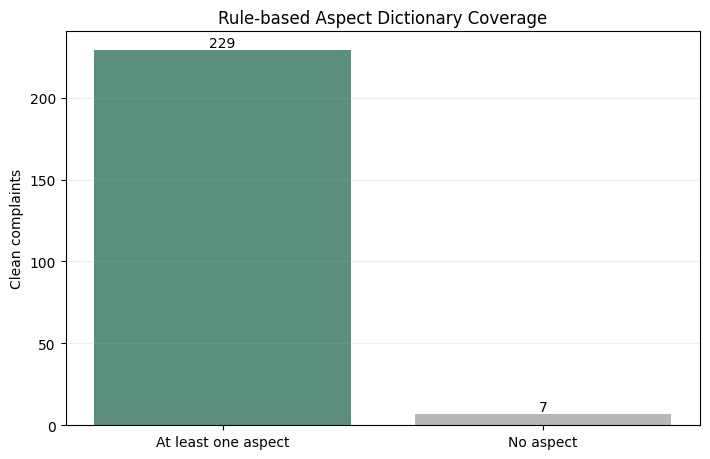

PosixPath('reports/figures/sikayetvar_nlp_aspect/04_aspect_coverage.png')

In [15]:
text_document_n = int(nlp["nlp_text_normalized"].ne("").sum())
with_aspect_n = int(nlp["aspect_count"].gt(0).sum())
no_aspect_n = int(nlp["no_aspect_detected_flag"].sum())
aspect_coverage = pd.DataFrame([
    ("total_clean_rows", len(nlp)),
    ("text_documents", text_document_n),
    ("complaints_with_at_least_one_aspect", with_aspect_n),
    ("no_aspect_count", no_aspect_n),
    ("aspect_coverage_pct_all_clean_rows", 100*with_aspect_n/len(nlp)),
    ("aspect_coverage_pct_text_documents", 100*with_aspect_n/text_document_n),
    ("mean_aspects_per_complaint", nlp["aspect_count"].mean()),
    ("median_aspects_per_complaint", nlp["aspect_count"].median()),
], columns=["metric", "value"])
display(aspect_coverage)

coverage_plot = pd.Series({"At least one aspect": with_aspect_n, "No aspect": no_aspect_n})
fig, ax = plt.subplots(figsize=(7.2, 4.7))
bars = ax.bar(coverage_plot.index, coverage_plot.values, color=["#5B8E7D", "#B8B8B8"])
ax.bar_label(bars); ax.set(title="Rule-based Aspect Dictionary Coverage", ylabel="Clean complaints")
ax.grid(axis="y", alpha=.2)
save_fig(fig, "04_aspect_coverage.png")


In [16]:
explain_figure(
    "Clean complaint rowları en az bir dictionary aspect eşleşmesi bulunan ve bulunmayan olarak ayrılır.",
    f"Coverage all-clean rows üzerinde %{100*with_aspect_n/len(nlp):.1f}; no-aspect n={no_aspect_n}.",
    "Dictionary'nin corpusun ne kadarını yapılandırabildiğini ve manual review ihtiyacını gösterir.",
    "Yüksek coverage doğruluk garantisi değildir; geniş keywords false positive, dar keywords false negative yaratabilir."
)


### Grafik nasıl okunur?
Clean complaint rowları en az bir dictionary aspect eşleşmesi bulunan ve bulunmayan olarak ayrılır.

### Ne görüyoruz?
Coverage all-clean rows üzerinde %97.0; no-aspect n=7.

### Neden önemli?
Dictionary'nin corpusun ne kadarını yapılandırabildiğini ve manual review ihtiyacını gösterir.

### Dikkat edilmesi gereken nokta
Yüksek coverage doğruluk garantisi değildir; geniş keywords false positive, dar keywords false negative yaratabilir.

## 12. Overall aspect frequencies

,aspect,complaint_count,mention_rate_pct,unique_hotel_count,unique_area_count,company_response_count,company_response_rate_within_aspect,median_view_count,median_complaint_word_count
0,STAFF_SERVICE,159,67.372881,28,11,29,18.238994,662.0,165.0
1,ROOM,142,60.169492,27,10,26,18.309859,900.0,165.5
2,MANAGEMENT_COMMUNICATION,140,59.322034,28,11,24,17.142857,558.0,161.0
3,PAYMENT_REFUND,123,52.118644,27,10,19,15.447154,836.0,159.0
4,FOOD_BEVERAGE,122,51.694915,26,9,22,18.032787,876.0,184.0
5,PRICE_VALUE,113,47.881356,27,11,23,20.353982,597.0,161.0
6,CLEANLINESS_HYGIENE,106,44.915254,22,9,15,14.150943,855.0,166.5
7,RESERVATION,94,39.830508,24,10,19,20.212766,788.5,153.5
8,FACILITIES_MAINTENANCE,92,38.983051,23,9,16,17.391304,597.0,170.0
9,BEACH_SEA,70,29.661017,21,8,15,21.428571,979.5,170.5


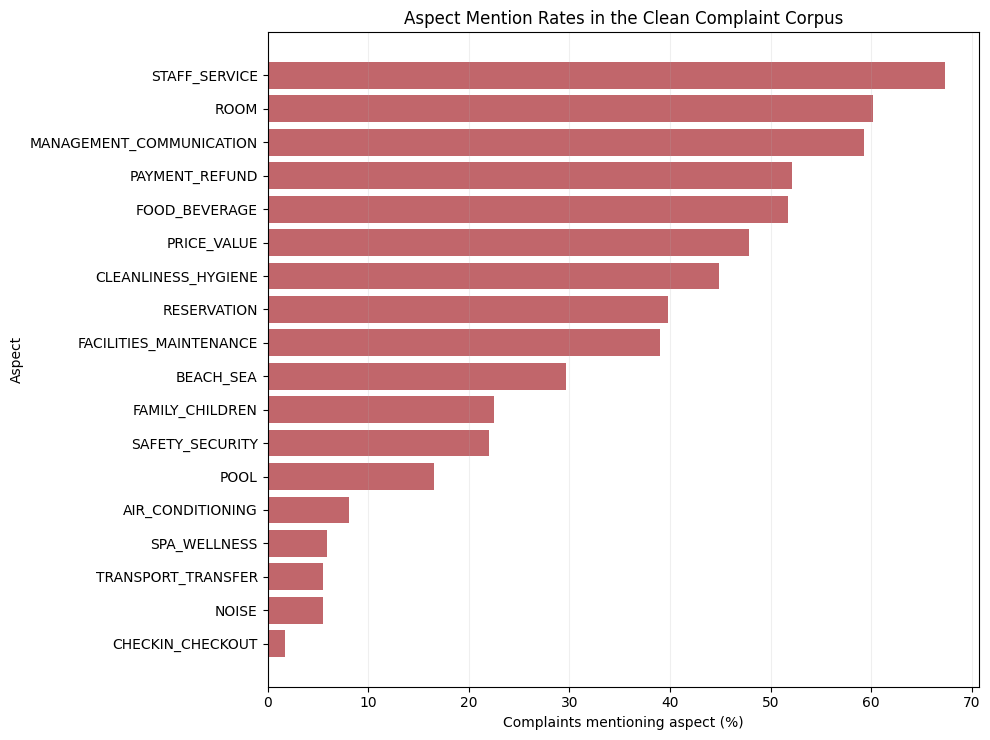

PosixPath('reports/figures/sikayetvar_nlp_aspect/05_aspect_mention_rates.png')

In [17]:
aspect_frequency = aspect_frequency_table(nlp)
display(aspect_frequency)
plot_frequency = aspect_frequency.sort_values("mention_rate_pct")
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.barh(plot_frequency["aspect"], plot_frequency["mention_rate_pct"], color="#C1666B")
ax.set(title="Aspect Mention Rates in the Clean Complaint Corpus", xlabel="Complaints mentioning aspect (%)", ylabel="Aspect")
ax.grid(axis="x", alpha=.2)
save_fig(fig, "05_aspect_mention_rates.png")


In [18]:
top_aspect = aspect_frequency.iloc[0]
explain_figure(
    "Her bar, aspect'in geçtiği unique clean complaint sayısının 236 clean rowa oranıdır; multi-label olduğu için barlar toplamı %100 değildir.",
    f"En sık eşleşen aspect {top_aspect['aspect']}: n={int(top_aspect['complaint_count'])}, %{top_aspect['mention_rate_pct']:.1f}.",
    "Negative customer voice corpusunun başlıca hizmet/problem başlıklarını karşılaştırılabilir hale getirir.",
    "Mention rate gerçek müşteri problem oranı değildir; dictionary coverage ve multi-label overlap içerir."
)


### Grafik nasıl okunur?
Her bar, aspect'in geçtiği unique clean complaint sayısının 236 clean rowa oranıdır; multi-label olduğu için barlar toplamı %100 değildir.

### Ne görüyoruz?
En sık eşleşen aspect STAFF_SERVICE: n=159, %67.4.

### Neden önemli?
Negative customer voice corpusunun başlıca hizmet/problem başlıklarını karşılaştırılabilir hale getirir.

### Dikkat edilmesi gereken nokta
Mention rate gerçek müşteri problem oranı değildir; dictionary coverage ve multi-label overlap içerir.

## 13. Hotel × aspect analysis

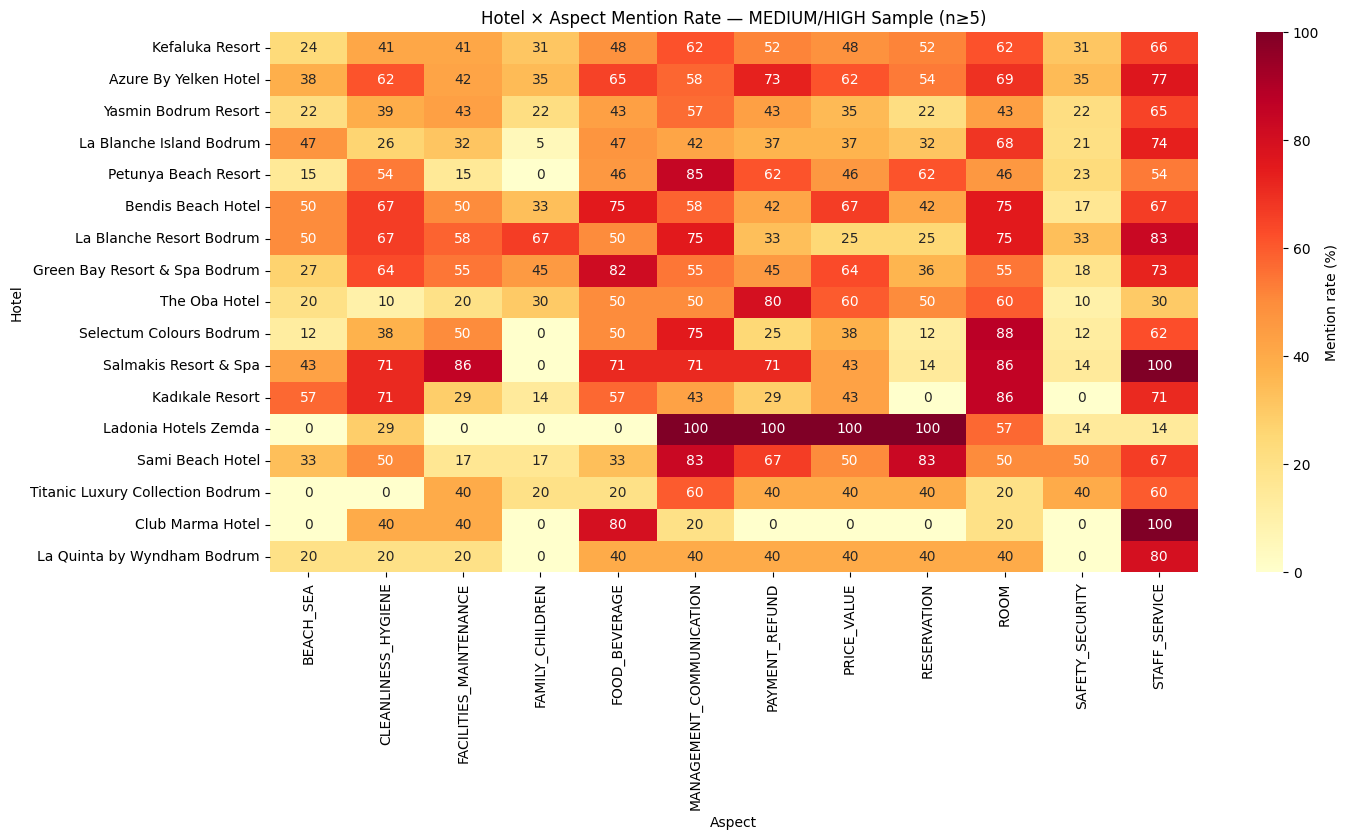

PosixPath('reports/figures/sikayetvar_nlp_aspect/06_hotel_aspect_heatmap.png')

In [19]:
hotel_aspect = group_aspect_matrix(
    nlp, ["hotel_id", "hotel_name"], small_n_threshold=MIN_HOTEL_N
).rename(columns={"group_n": "hotel_n"})
hotel_aspect = hotel_aspect.merge(
    readiness[["hotel_id", "nlp_sample_tier"]], on="hotel_id", how="left", validate="many_to_one"
)
eligible_hotels = readiness.loc[readiness["matched_complaint_count"].ge(MIN_HOTEL_N), "hotel_name"]
major_aspects = aspect_frequency.head(12)["aspect"].tolist()
hotel_heatmap = hotel_aspect[
    hotel_aspect["hotel_name"].isin(eligible_hotels) & hotel_aspect["aspect"].isin(major_aspects)
].pivot(index="hotel_name", columns="aspect", values="aspect_mention_rate_pct")
hotel_order = hotel_eda[hotel_eda["matched_complaint_count"].ge(MIN_HOTEL_N)]["hotel_name"]
hotel_heatmap = hotel_heatmap.reindex([name for name in hotel_order if name in hotel_heatmap.index])
fig, ax = plt.subplots(figsize=(14.5, 8.5))
sns.heatmap(hotel_heatmap, cmap="YlOrRd", vmin=0, vmax=100, annot=True, fmt=".0f", ax=ax, cbar_kws={"label":"Mention rate (%)"})
ax.set(title=f"Hotel × Aspect Mention Rate — MEDIUM/HIGH Sample (n≥{MIN_HOTEL_N})", xlabel="Aspect", ylabel="Hotel")
save_fig(fig, "06_hotel_aspect_heatmap.png")


In [20]:
explain_figure(
    "Renk complaint sayısı değil, her hotelin own clean complaint corpusunda aspect mention rate yüzdesidir; yalnız n>=5 hotel'ler gösterilir.",
    f"Heatmap {hotel_heatmap.shape[0]} yeterli-sample hotel ve {hotel_heatmap.shape[1]} major aspect içerir.",
    "Farklı corpus büyüklüklerindeki hotel'leri normalized relative emphasis ile karşılaştırır.",
    "n=5 hâlâ oynaktır; selection/mapping bias sürer. Koyu hücre hotel kalitesi veya gerçek risk rate değildir."
)


### Grafik nasıl okunur?
Renk complaint sayısı değil, her hotelin own clean complaint corpusunda aspect mention rate yüzdesidir; yalnız n>=5 hotel'ler gösterilir.

### Ne görüyoruz?
Heatmap 17 yeterli-sample hotel ve 12 major aspect içerir.

### Neden önemli?
Farklı corpus büyüklüklerindeki hotel'leri normalized relative emphasis ile karşılaştırır.

### Dikkat edilmesi gereken nokta
n=5 hâlâ oynaktır; selection/mapping bias sürer. Koyu hücre hotel kalitesi veya gerçek risk rate değildir.

In [21]:
def top_aspect_summary(matrix, group_column, n_column, minimum_n):
    rows = []
    for group_name, part in matrix[matrix[n_column].ge(minimum_n)].groupby(group_column):
        ranked = part.sort_values(["aspect_mention_rate_pct", "aspect_count"], ascending=False).head(3)
        row = {group_column: group_name, n_column: int(part[n_column].iloc[0])}
        for rank, item in enumerate(ranked.itertuples(), 1):
            row[f"top_aspect_{rank}"] = item.aspect
            row[f"top_aspect_{rank}_rate_pct"] = item.aspect_mention_rate_pct
        rows.append(row)
    return pd.DataFrame(rows)

hotel_top_aspects = top_aspect_summary(hotel_aspect, "hotel_name", "hotel_n", MIN_HOTEL_N)
display(hotel_top_aspects)


,hotel_name,hotel_n,top_aspect_1,top_aspect_1_rate_pct,top_aspect_2,top_aspect_2_rate_pct,top_aspect_3,top_aspect_3_rate_pct
0,Azure By Yelken Hotel,26,STAFF_SERVICE,76.923077,PAYMENT_REFUND,73.076923,ROOM,69.230769
1,Bendis Beach Hotel,12,FOOD_BEVERAGE,75.000000,ROOM,75.000000,STAFF_SERVICE,66.666667
2,Club Marma Hotel,5,STAFF_SERVICE,100.000000,FOOD_BEVERAGE,80.000000,CLEANLINESS_HYGIENE,40.000000
3,Green Bay Resort & Spa Bodrum,11,FOOD_BEVERAGE,81.818182,STAFF_SERVICE,72.727273,CLEANLINESS_HYGIENE,63.636364
4,Kadıkale Resort,7,ROOM,85.714286,STAFF_SERVICE,71.428571,CLEANLINESS_HYGIENE,71.428571
5,Kefaluka Resort,29,STAFF_SERVICE,65.517241,ROOM,62.068966,MANAGEMENT_COMMUNICATION,62.068966
6,La Blanche Island Bodrum,19,STAFF_SERVICE,73.684211,ROOM,68.421053,FOOD_BEVERAGE,47.368421
7,La Blanche Resort Bodrum,12,STAFF_SERVICE,83.333333,ROOM,75.000000,MANAGEMENT_COMMUNICATION,75.000000
8,La Quinta by Wyndham Bodrum,5,STAFF_SERVICE,80.000000,FOOD_BEVERAGE,40.000000,ROOM,40.000000
9,Ladonia Hotels Zemda,7,RESERVATION,100.000000,PAYMENT_REFUND,100.000000,PRICE_VALUE,100.000000


## 14. Area × aspect analysis

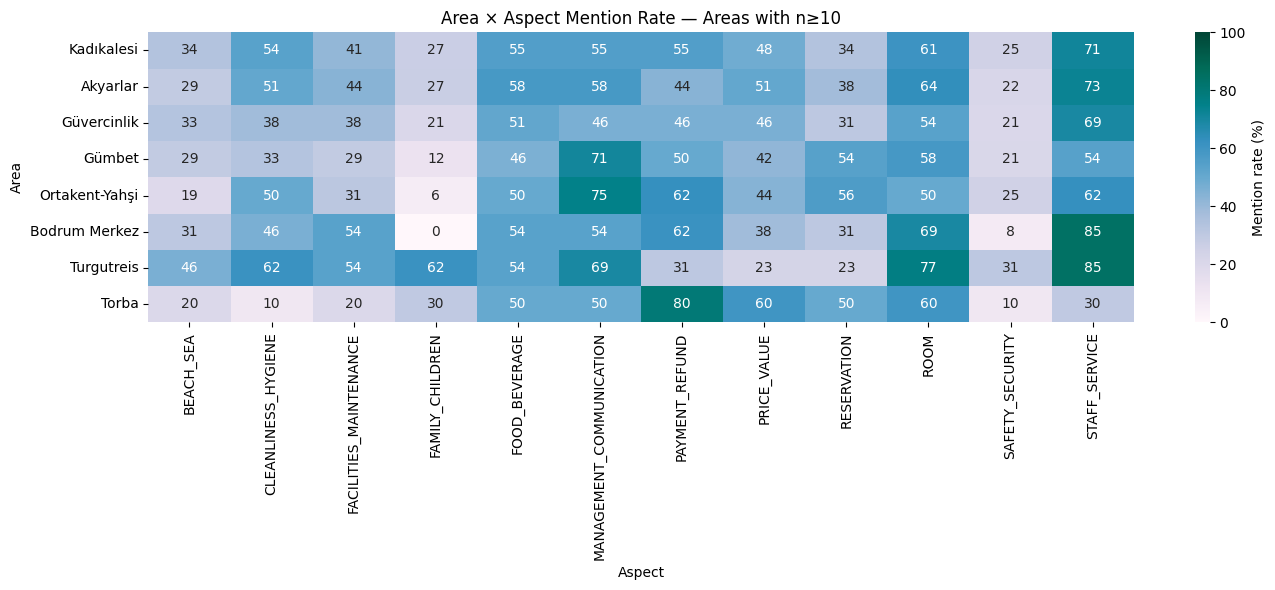

PosixPath('reports/figures/sikayetvar_nlp_aspect/07_area_aspect_heatmap.png')

In [22]:
area_aspect = group_aspect_matrix(nlp, ["area"], small_n_threshold=MIN_AREA_N).rename(columns={"group_n": "area_n"})
area_aspect = area_aspect.merge(
    area_eda[["area", "mapping_coverage_pct", "coverage_flag"]], on="area", how="left", validate="many_to_one"
)
eligible_areas = area_aspect.loc[area_aspect["area_n"].ge(MIN_AREA_N), "area"].unique()
area_heatmap = area_aspect[
    area_aspect["area"].isin(eligible_areas) & area_aspect["aspect"].isin(major_aspects)
].pivot(index="area", columns="aspect", values="aspect_mention_rate_pct")
area_order = area_eda[area_eda["matched_complaint_count"].ge(MIN_AREA_N)]["area"]
area_heatmap = area_heatmap.reindex([area for area in area_order if area in area_heatmap.index])
fig, ax = plt.subplots(figsize=(14.0, 6.0))
sns.heatmap(area_heatmap, cmap="PuBuGn", vmin=0, vmax=100, annot=True, fmt=".0f", ax=ax, cbar_kws={"label":"Mention rate (%)"})
ax.set(title=f"Area × Aspect Mention Rate — Areas with n≥{MIN_AREA_N}", xlabel="Aspect", ylabel="Area")
save_fig(fig, "07_area_aspect_heatmap.png")


In [23]:
explain_figure(
    "Renk her area'nın matched clean complaint corpusunda aspect mention rate'idir; count değildir. n<10 area'lar ana heatmap dışında tutulur.",
    f"Heatmap {area_heatmap.shape[0]} area içerir; area mapping coverage ayrı CSV'de korunur.",
    "Destination complaint themes için normalized descriptive karşılaştırma sağlar.",
    "Area mapping coverage eşit değildir ve project hotel karması değişir; renkler tüm area müşterilerini temsil etmez."
)


### Grafik nasıl okunur?
Renk her area'nın matched clean complaint corpusunda aspect mention rate'idir; count değildir. n<10 area'lar ana heatmap dışında tutulur.

### Ne görüyoruz?
Heatmap 8 area içerir; area mapping coverage ayrı CSV'de korunur.

### Neden önemli?
Destination complaint themes için normalized descriptive karşılaştırma sağlar.

### Dikkat edilmesi gereken nokta
Area mapping coverage eşit değildir ve project hotel karması değişir; renkler tüm area müşterilerini temsil etmez.

In [24]:
area_top_aspects = top_aspect_summary(area_aspect, "area", "area_n", MIN_AREA_N)
display(area_top_aspects)


,area,area_n,top_aspect_1,top_aspect_1_rate_pct,top_aspect_2,top_aspect_2_rate_pct,top_aspect_3,top_aspect_3_rate_pct
0,Akyarlar,55,STAFF_SERVICE,72.727273,ROOM,63.636364,FOOD_BEVERAGE,58.181818
1,Bodrum Merkez,13,STAFF_SERVICE,84.615385,ROOM,69.230769,PAYMENT_REFUND,61.538462
2,Gümbet,24,MANAGEMENT_COMMUNICATION,70.833333,ROOM,58.333333,STAFF_SERVICE,54.166667
3,Güvercinlik,39,STAFF_SERVICE,69.230769,ROOM,53.846154,FOOD_BEVERAGE,51.282051
4,Kadıkalesi,56,STAFF_SERVICE,71.428571,ROOM,60.714286,FOOD_BEVERAGE,55.357143
5,Ortakent-Yahşi,16,MANAGEMENT_COMMUNICATION,75.000000,STAFF_SERVICE,62.500000,PAYMENT_REFUND,62.500000
6,Torba,10,PAYMENT_REFUND,80.000000,ROOM,60.000000,PRICE_VALUE,60.000000
7,Turgutreis,13,STAFF_SERVICE,84.615385,ROOM,76.923077,MANAGEMENT_COMMUNICATION,69.230769


## 15. Aspect lift

,hotel_name,hotel_n,aspect,hotel_mention_rate_pct,overall_mention_rate_pct,lift_pp,small_n_flag,nlp_sample_tier
422,Azure By Yelken Hotel,26,PAYMENT_REFUND,73.076923,52.118644,20.958279,False,HIGH_SAMPLE
415,Azure By Yelken Hotel,26,CLEANLINESS_HYGIENE,61.538462,44.915254,16.623207,False,HIGH_SAMPLE
419,Azure By Yelken Hotel,26,POOL,30.769231,16.525424,14.243807,False,HIGH_SAMPLE
2,Bendis Beach Hotel,12,FOOD_BEVERAGE,75.000000,51.694915,23.305085,False,MEDIUM_SAMPLE
1,Bendis Beach Hotel,12,CLEANLINESS_HYGIENE,66.666667,44.915254,21.751412,False,MEDIUM_SAMPLE
4,Bendis Beach Hotel,12,BEACH_SEA,50.000000,29.661017,20.338983,False,MEDIUM_SAMPLE
18,Club Marma Hotel,5,STAFF_SERVICE,100.000000,67.372881,32.627119,False,MEDIUM_SAMPLE
20,Club Marma Hotel,5,FOOD_BEVERAGE,80.000000,51.694915,28.305085,False,MEDIUM_SAMPLE
24,Club Marma Hotel,5,FACILITIES_MAINTENANCE,40.000000,38.983051,1.016949,False,MEDIUM_SAMPLE
344,Green Bay Resort & Spa Bodrum,11,FOOD_BEVERAGE,81.818182,51.694915,30.123267,False,MEDIUM_SAMPLE


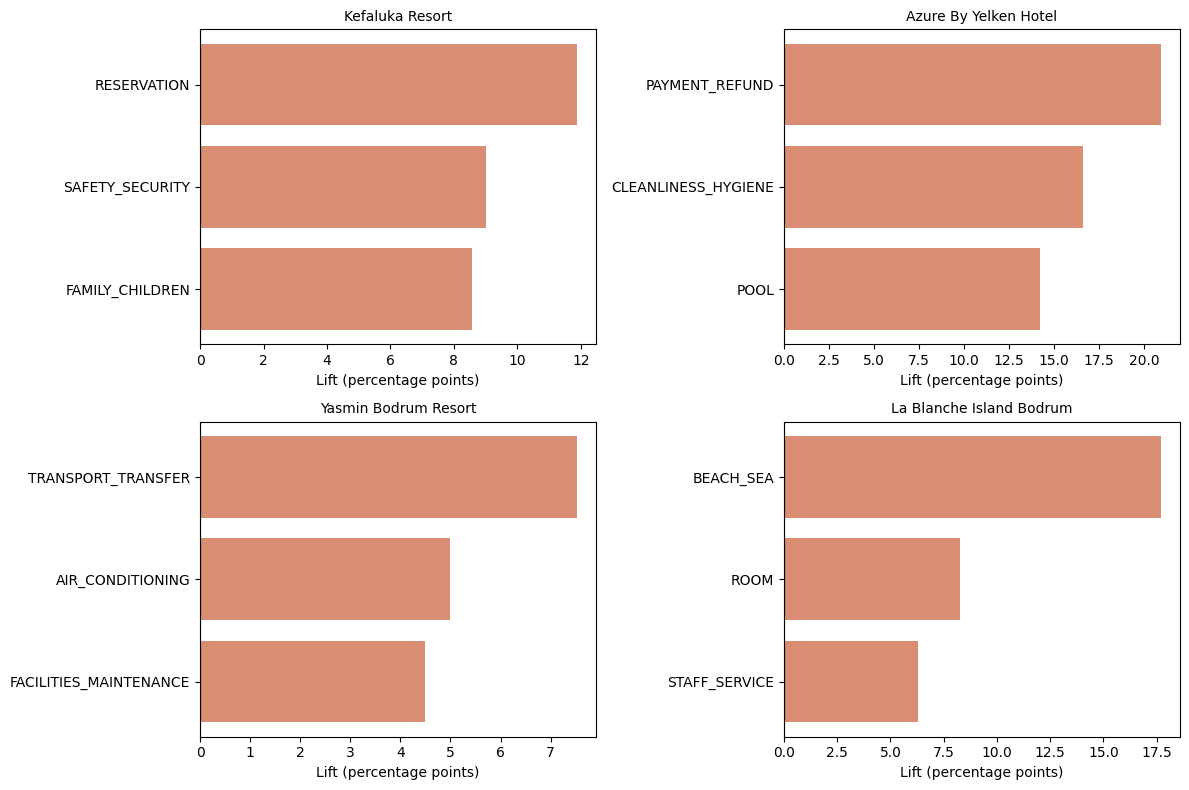

PosixPath('reports/figures/sikayetvar_nlp_aspect/08_hotel_aspect_lift.png')

In [25]:
overall_rates = aspect_frequency.set_index("aspect")["mention_rate_pct"]
hotel_lift = hotel_aspect.copy()
hotel_lift["overall_mention_rate_pct"] = hotel_lift["aspect"].map(overall_rates)
hotel_lift["hotel_mention_rate_pct"] = hotel_lift["aspect_mention_rate_pct"]
hotel_lift["lift_pp"] = hotel_lift["hotel_mention_rate_pct"] - hotel_lift["overall_mention_rate_pct"]
hotel_lift = hotel_lift[[
    "hotel_name", "hotel_n", "aspect", "hotel_mention_rate_pct", "overall_mention_rate_pct", "lift_pp", "small_n_flag", "nlp_sample_tier"
]]

area_lift = area_aspect.copy()
area_lift["overall_mention_rate_pct"] = area_lift["aspect"].map(overall_rates)
area_lift["area_mention_rate_pct"] = area_lift["aspect_mention_rate_pct"]
area_lift["lift_pp"] = area_lift["area_mention_rate_pct"] - area_lift["overall_mention_rate_pct"]

top_hotel_lift = hotel_lift[~hotel_lift["small_n_flag"]].sort_values(
    ["hotel_name", "lift_pp"], ascending=[True, False]
).groupby("hotel_name").head(3)
display(top_hotel_lift.head(30))

selected_lift = top_hotel_lift[top_hotel_lift["hotel_name"].isin(selected_names)]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, hotel_name in zip(axes.ravel(), selected_names):
    part = selected_lift[selected_lift["hotel_name"] == hotel_name].sort_values("lift_pp")
    ax.barh(part["aspect"], part["lift_pp"], color="#D98E73")
    ax.axvline(0, color="#555", linewidth=.8); ax.set_title(hotel_name, fontsize=10); ax.set_xlabel("Lift (percentage points)")
save_fig(fig, "08_hotel_aspect_lift.png")


In [26]:
explain_figure(
    "Lift, hotel mention rate eksi overall corpus mention rate'tir; pozitif değer yalnız corpus içi relative emphasis gösterir.",
    "Seçili dört yüksek-volume hotel için en yüksek üç pozitif aspect lift gösterilir.",
    "Normalized profile farklarını segmentation feature adayı haline getirir.",
    "Lift gerçek risk/kalite farkı değildir; küçük-n hotel'ler dışarıda olsa da selection bias ve dictionary hatası kalır."
)


### Grafik nasıl okunur?
Lift, hotel mention rate eksi overall corpus mention rate'tir; pozitif değer yalnız corpus içi relative emphasis gösterir.

### Ne görüyoruz?
Seçili dört yüksek-volume hotel için en yüksek üç pozitif aspect lift gösterilir.

### Neden önemli?
Normalized profile farklarını segmentation feature adayı haline getirir.

### Dikkat edilmesi gereken nokta
Lift gerçek risk/kalite farkı değildir; küçük-n hotel'ler dışarıda olsa da selection bias ve dictionary hatası kalır.

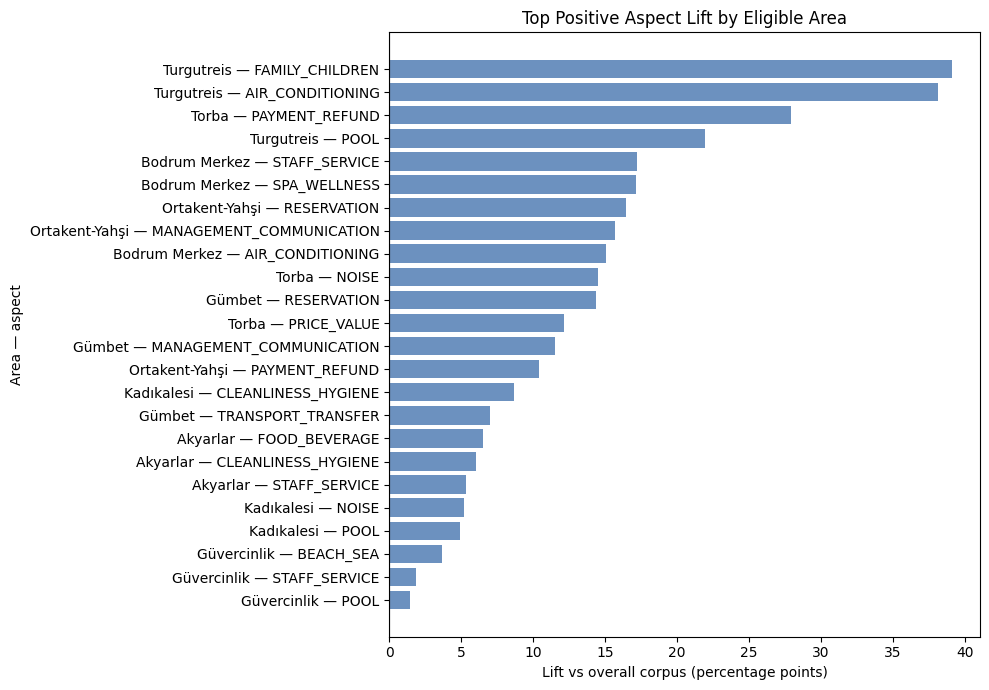

PosixPath('reports/figures/sikayetvar_nlp_aspect/09_area_aspect_lift.png')

In [27]:
eligible_area_lift = area_lift[area_lift["area_n"].ge(MIN_AREA_N)]
top_area_lift = eligible_area_lift.sort_values(["area", "lift_pp"], ascending=[True, False]).groupby("area").head(3)
fig, ax = plt.subplots(figsize=(10, 7))
plot_area_lift = top_area_lift.copy()
plot_area_lift["label"] = plot_area_lift["area"] + " — " + plot_area_lift["aspect"]
plot_area_lift = plot_area_lift.sort_values("lift_pp")
ax.barh(plot_area_lift["label"], plot_area_lift["lift_pp"], color="#6C91BF")
ax.axvline(0, color="#555", linewidth=.8)
ax.set(title="Top Positive Aspect Lift by Eligible Area", xlabel="Lift vs overall corpus (percentage points)", ylabel="Area — aspect")
save_fig(fig, "09_area_aspect_lift.png")


In [28]:
explain_figure(
    "Her yeterli-sample area için overall corpus oranına göre en yüksek üç pozitif aspect farkı gösterilir.",
    f"Yalnız area_n≥{MIN_AREA_N} olan gruplar dahildir.",
    "Area düzeyindeki relative emphasis'i sade bir investigation queue'ya dönüştürür.",
    "Mapping coverage ve hotel composition farklıdır; lift tüm destinasyon deneyimi veya problem rate değildir."
)


### Grafik nasıl okunur?
Her yeterli-sample area için overall corpus oranına göre en yüksek üç pozitif aspect farkı gösterilir.

### Ne görüyoruz?
Yalnız area_n≥10 olan gruplar dahildir.

### Neden önemli?
Area düzeyindeki relative emphasis'i sade bir investigation queue'ya dönüştürür.

### Dikkat edilmesi gereken nokta
Mapping coverage ve hotel composition farklıdır; lift tüm destinasyon deneyimi veya problem rate değildir.

## 16. Aspect co-occurrence

,aspect_a,aspect_b,cooccurrence_count,cooccurrence_rate_pct,jaccard_similarity
0,STAFF_SERVICE,ROOM,108,45.762712,0.559585
1,STAFF_SERVICE,FOOD_BEVERAGE,107,45.338983,0.614943
2,STAFF_SERVICE,MANAGEMENT_COMMUNICATION,94,39.830508,0.458537
3,FOOD_BEVERAGE,ROOM,92,38.983051,0.534884
4,PAYMENT_REFUND,MANAGEMENT_COMMUNICATION,89,37.711864,0.511494
5,STAFF_SERVICE,CLEANLINESS_HYGIENE,87,36.864407,0.488764
6,ROOM,MANAGEMENT_COMMUNICATION,87,36.864407,0.446154
7,CLEANLINESS_HYGIENE,ROOM,86,36.440678,0.530864
8,PAYMENT_REFUND,PRICE_VALUE,85,36.016949,0.562914
9,ROOM,PAYMENT_REFUND,81,34.322034,0.440217


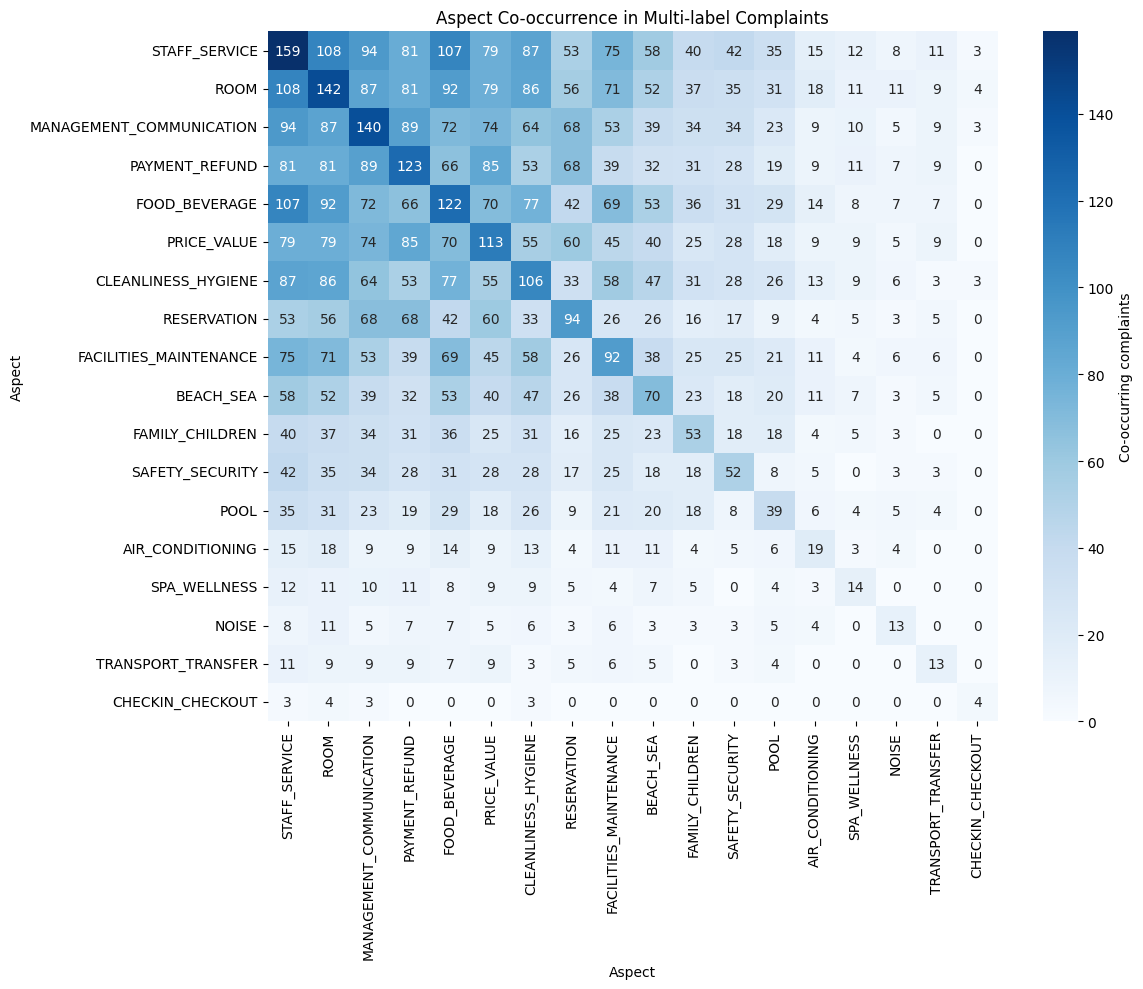

PosixPath('reports/figures/sikayetvar_nlp_aspect/10_aspect_cooccurrence_heatmap.png')

In [29]:
cooccurrence = aspect_cooccurrence_table(nlp, minimum_support=3)
display(cooccurrence.head(20))
co_matrix = pd.DataFrame(0, index=CANONICAL_ASPECTS, columns=CANONICAL_ASPECTS, dtype=float)
for aspect in CANONICAL_ASPECTS:
    co_matrix.loc[aspect, aspect] = int(nlp[f"aspect_{aspect.lower()}"].sum())
for row in cooccurrence.itertuples():
    co_matrix.loc[row.aspect_a, row.aspect_b] = row.cooccurrence_count
    co_matrix.loc[row.aspect_b, row.aspect_a] = row.cooccurrence_count
ordered_aspects = aspect_frequency["aspect"].tolist()
co_matrix = co_matrix.loc[ordered_aspects, ordered_aspects]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(co_matrix, cmap="Blues", annot=True, fmt=".0f", ax=ax, cbar_kws={"label":"Co-occurring complaints"})
ax.set(title="Aspect Co-occurrence in Multi-label Complaints", xlabel="Aspect", ylabel="Aspect")
save_fig(fig, "10_aspect_cooccurrence_heatmap.png")


In [30]:
top_pair = cooccurrence.iloc[0]
explain_figure(
    "Off-diagonal hücreler iki aspect'in aynı complaint'te birlikte kaç kez geçtiğini; diagonal aspect'in total complaint count'unu gösterir.",
    f"En sık çift {top_pair['aspect_a']} × {top_pair['aspect_b']}: n={int(top_pair['cooccurrence_count'])}.",
    "Tekil problem başlıkları yerine birlikte yaşanan complaint örüntülerini gösterir.",
    "Broad keywords doğal olarak co-occurrence'ı yükseltebilir; count nedensellik veya problem şiddeti değildir."
)


### Grafik nasıl okunur?
Off-diagonal hücreler iki aspect'in aynı complaint'te birlikte kaç kez geçtiğini; diagonal aspect'in total complaint count'unu gösterir.

### Ne görüyoruz?
En sık çift STAFF_SERVICE × ROOM: n=108.

### Neden önemli?
Tekil problem başlıkları yerine birlikte yaşanan complaint örüntülerini gösterir.

### Dikkat edilmesi gereken nokta
Broad keywords doğal olarak co-occurrence'ı yükseltebilir; count nedensellik veya problem şiddeti değildir.

## 17. Company response by aspect

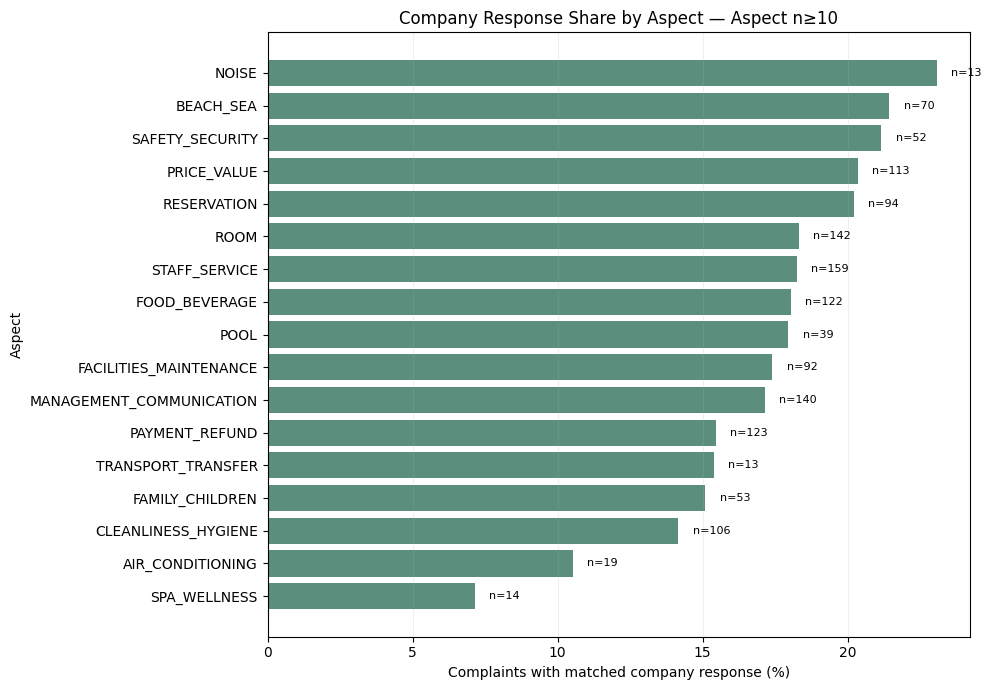

PosixPath('reports/figures/sikayetvar_nlp_aspect/11_aspect_company_response_rate.png')

In [31]:
aspect_response = aspect_frequency[[
    "aspect", "complaint_count", "company_response_count", "company_response_rate_within_aspect",
    "median_view_count", "median_complaint_word_count",
]].copy()
eligible_response = aspect_response[aspect_response["complaint_count"].ge(10)].sort_values("company_response_rate_within_aspect")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(eligible_response["aspect"], eligible_response["company_response_rate_within_aspect"], color="#5B8E7D")
for index, row in enumerate(eligible_response.itertuples()):
    ax.text(row.company_response_rate_within_aspect + .5, index, f"n={row.complaint_count}", va="center", fontsize=8)
ax.set(title="Company Response Share by Aspect — Aspect n≥10", xlabel="Complaints with matched company response (%)", ylabel="Aspect")
ax.grid(axis="x", alpha=.2)
save_fig(fig, "11_aspect_company_response_rate.png")


In [32]:
explain_figure(
    "Her bar, aspect geçen complaints içinde matched company response görülen payı; etiket aspect complaint n'ini gösterir.",
    f"Yeterli-support aspect'lerde response share %{eligible_response.company_response_rate_within_aspect.min():.1f}–%{eligible_response.company_response_rate_within_aspect.max():.1f} aralığındadır.",
    "Hangi complaint başlıklarında kurum yanıtının corpus içinde daha sık görüldüğünü descriptif gösterir.",
    "Company response çözüm değildir; hotel/brand response strategy ve aspect-hotel karması sonucu etkiler."
)


### Grafik nasıl okunur?
Her bar, aspect geçen complaints içinde matched company response görülen payı; etiket aspect complaint n'ini gösterir.

### Ne görüyoruz?
Yeterli-support aspect'lerde response share %7.1–%23.1 aralığındadır.

### Neden önemli?
Hangi complaint başlıklarında kurum yanıtının corpus içinde daha sık görüldüğünü descriptif gösterir.

### Dikkat edilmesi gereken nokta
Company response çözüm değildir; hotel/brand response strategy ve aspect-hotel karması sonucu etkiler.

,term,token_count,document_count,document_share_pct
0,saygılarımızla,37,37,94.871795
1,isteriz,65,30,76.923077
2,misafir,63,29,74.358974
3,öncelikle,29,28,71.794872
4,belirtmek,46,27,69.230769
5,misafirimiz,27,25,64.102564
6,olup,32,23,58.974359
7,ederiz,31,23,58.974359
8,sayın,23,23,58.974359
9,hizmet,46,22,56.410256


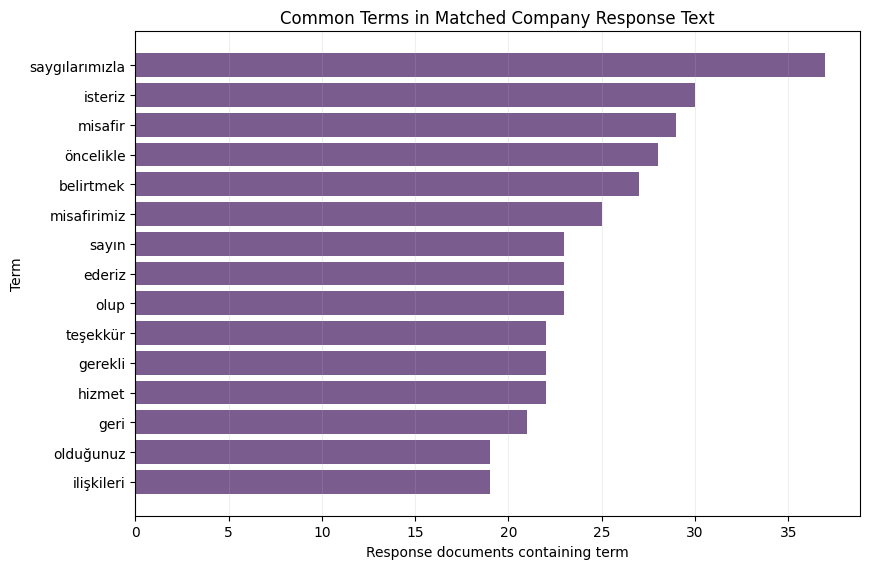

PosixPath('reports/figures/sikayetvar_nlp_aspect/12_company_response_terms.png')

In [33]:
response_texts = nlp.loc[nlp["company_response_text_clean"].notna(), "company_response_text_clean"]
response_terms = term_frequency_table(response_texts, n=1, min_document_count=2, extra_stopwords=domain_stopwords)
display(response_terms.head(20))
fig, ax = plt.subplots(figsize=(8.8, 5.8))
plot_response_terms = response_terms.head(15).sort_values("document_count")
ax.barh(plot_response_terms["term"], plot_response_terms["document_count"], color="#7A5C8E")
ax.set(title="Common Terms in Matched Company Response Text", xlabel="Response documents containing term", ylabel="Term")
ax.grid(axis="x", alpha=.2)
save_fig(fig, "12_company_response_terms.png")


In [34]:
explain_figure(
    "Matched company response textlerinde standard/domain stopwords sonrası document frequency gösterilir.",
    f"Response-text corpus n={len(response_texts)}; ağır topic modeling uygulanmaz.",
    "Standardized communication phrase adaylarını görünür kılar.",
    "Benzer veya sık response language firmanın müşteriyi önemsemediği kanıtı değildir; template kullanımı olabilir."
)


### Grafik nasıl okunur?
Matched company response textlerinde standard/domain stopwords sonrası document frequency gösterilir.

### Ne görüyoruz?
Response-text corpus n=39; ağır topic modeling uygulanmaz.

### Neden önemli?
Standardized communication phrase adaylarını görünür kılar.

### Dikkat edilmesi gereken nokta
Benzer veya sık response language firmanın müşteriyi önemsemediği kanıtı değildir; template kullanımı olabilir.

## 18. Response time by aspect

,aspect,complaint_count,company_response_count,response_date_available_n,company_response_rate_within_aspect,median_response_time_days,q25_response_time_days,q75_response_time_days
0,STAFF_SERVICE,159,29,27,18.238994,0.790972,0.290625,1.526042
3,ROOM,142,26,25,18.309859,0.689583,0.271528,1.715972
15,MANAGEMENT_COMMUNICATION,140,24,22,17.142857,0.643403,0.166319,1.259375
8,PAYMENT_REFUND,123,19,18,15.447154,0.643403,0.099479,1.261458
2,FOOD_BEVERAGE,122,22,22,18.032787,0.643403,0.281076,1.621007
9,PRICE_VALUE,113,23,22,20.353982,0.686111,0.153819,1.621007
1,CLEANLINESS_HYGIENE,106,15,14,14.150943,0.467361,0.063021,0.986632
7,RESERVATION,94,19,18,20.212766,0.741667,0.318056,1.018229
6,FACILITIES_MAINTENANCE,92,16,16,17.391304,0.859028,0.472222,1.730208
4,BEACH_SEA,70,15,15,21.428571,0.689583,0.277083,4.294097


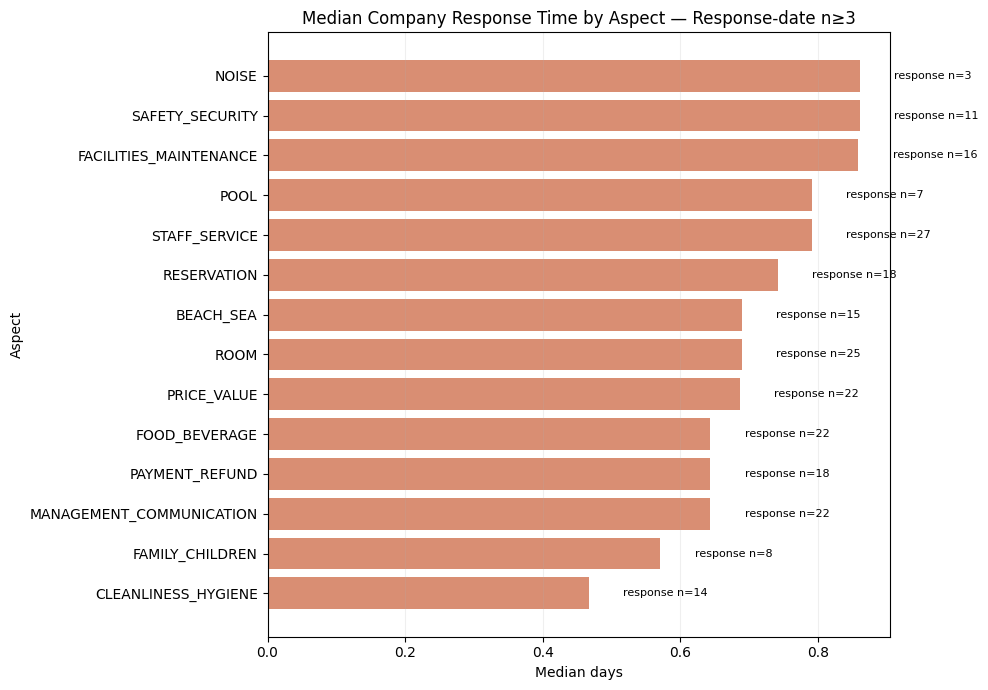

PosixPath('reports/figures/sikayetvar_nlp_aspect/13_aspect_response_time.png')

In [35]:
nlp["response_time_days"] = (
    nlp["company_response_date_parsed"] - nlp["complaint_date"]
).dt.total_seconds() / 86400
nlp.loc[nlp["response_time_days"].lt(0), "response_time_days"] = np.nan
response_rows = []
for aspect in CANONICAL_ASPECTS:
    subset = nlp[nlp[f"aspect_{aspect.lower()}"]]
    valid = subset["response_time_days"].dropna()
    response_rows.append({
        "aspect": aspect,
        "complaint_count": len(subset),
        "company_response_count": int(subset["company_response_exists_clean"].sum()),
        "response_date_available_n": len(valid),
        "company_response_rate_within_aspect": 100*subset["company_response_exists_clean"].mean() if len(subset) else np.nan,
        "median_response_time_days": valid.median(),
        "q25_response_time_days": valid.quantile(.25),
        "q75_response_time_days": valid.quantile(.75),
    })
aspect_response_summary = pd.DataFrame(response_rows).sort_values("complaint_count", ascending=False)
display(aspect_response_summary)
response_time_plot = aspect_response_summary[aspect_response_summary["response_date_available_n"].ge(MIN_ASPECT_RESPONSE_N)].sort_values("median_response_time_days")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(response_time_plot["aspect"], response_time_plot["median_response_time_days"], color="#D98E73")
for index, row in enumerate(response_time_plot.itertuples()):
    ax.text(row.median_response_time_days + .05, index, f"response n={row.response_date_available_n}", va="center", fontsize=8)
ax.set(title=f"Median Company Response Time by Aspect — Response-date n≥{MIN_ASPECT_RESPONSE_N}", xlabel="Median days", ylabel="Aspect")
ax.grid(axis="x", alpha=.2)
save_fig(fig, "13_aspect_response_time.png")


In [36]:
explain_figure(
    "Yalnız en az üç calculable response lag'i bulunan aspect'lerde complaint-to-company-response median days gösterilir.",
    f"Grafikte {len(response_time_plot)} aspect vardır; exact n etiketlenir.",
    "Aspect bazında operasyonel response-speed farklılıklarını descriptif olarak gösterir.",
    "86 approximate complaint date, multi-label overlap ve düşük response n vardır; bu SLA veya çözüm süresi değildir."
)


### Grafik nasıl okunur?
Yalnız en az üç calculable response lag'i bulunan aspect'lerde complaint-to-company-response median days gösterilir.

### Ne görüyoruz?
Grafikte 14 aspect vardır; exact n etiketlenir.

### Neden önemli?
Aspect bazında operasyonel response-speed farklılıklarını descriptif olarak gösterir.

### Dikkat edilmesi gereken nokta
86 approximate complaint date, multi-label overlap ve düşük response n vardır; bu SLA veya çözüm süresi değildir.

## 19. Optional temporal aspect analysis

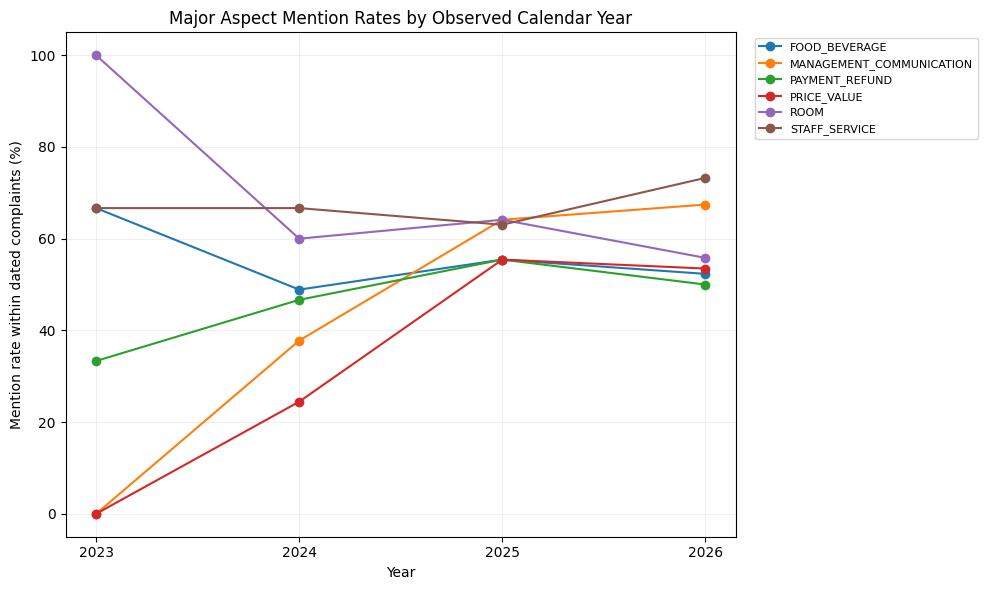

PosixPath('reports/figures/sikayetvar_nlp_aspect/14_major_aspects_by_year.png')

In [37]:
dated_nlp = nlp[nlp["complaint_date"].notna()].copy()
dated_nlp["year"] = dated_nlp["complaint_date"].dt.year.astype(int)
temporal_aspects = aspect_frequency.head(6)["aspect"].tolist()
temporal_rows = []
for year, group in dated_nlp.groupby("year"):
    for aspect in temporal_aspects:
        count = int(group[f"aspect_{aspect.lower()}"].sum())
        temporal_rows.append({
            "year": year, "year_n": len(group), "aspect": aspect, "aspect_count": count,
            "aspect_mention_rate_pct": 100*count/len(group),
            "partial_year_flag": year in {dated_nlp["year"].min(), dated_nlp["year"].max()},
        })
temporal_aspect_summary = pd.DataFrame(temporal_rows)
fig, ax = plt.subplots(figsize=(10, 6))
for aspect, part in temporal_aspect_summary.groupby("aspect"):
    ax.plot(part["year"], part["aspect_mention_rate_pct"], marker="o", label=aspect)
ax.set_xticks(sorted(dated_nlp["year"].unique()))
ax.set(title="Major Aspect Mention Rates by Observed Calendar Year", xlabel="Year", ylabel="Mention rate within dated complaints (%)")
ax.grid(alpha=.2); ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
save_fig(fig, "14_major_aspects_by_year.png")


In [38]:
explain_figure(
    "Her çizgi major aspect'in ilgili yıldaki dated clean complaints içinde mention rate'ini gösterir.",
    f"Date coverage {len(dated_nlp)}/{len(nlp)}; yalnız top-6 overall aspect gösterilir.",
    "Theme mix'in gözlenen erişilebilir tarih penceresinde nasıl değiştiğine exploratory bakış verir.",
    "2023 ve 2026 partial/accessibility-limited; platform historical completeness bilinmiyor. Trend veya turizm sezonu sonucu çıkarılamaz."
)


### Grafik nasıl okunur?
Her çizgi major aspect'in ilgili yıldaki dated clean complaints içinde mention rate'ini gösterir.

### Ne görüyoruz?
Date coverage 226/236; yalnız top-6 overall aspect gösterilir.

### Neden önemli?
Theme mix'in gözlenen erişilebilir tarih penceresinde nasıl değiştiğine exploratory bakış verir.

### Dikkat edilmesi gereken nokta
2023 ve 2026 partial/accessibility-limited; platform historical completeness bilinmiyor. Trend veya turizm sezonu sonucu çıkarılamaz.

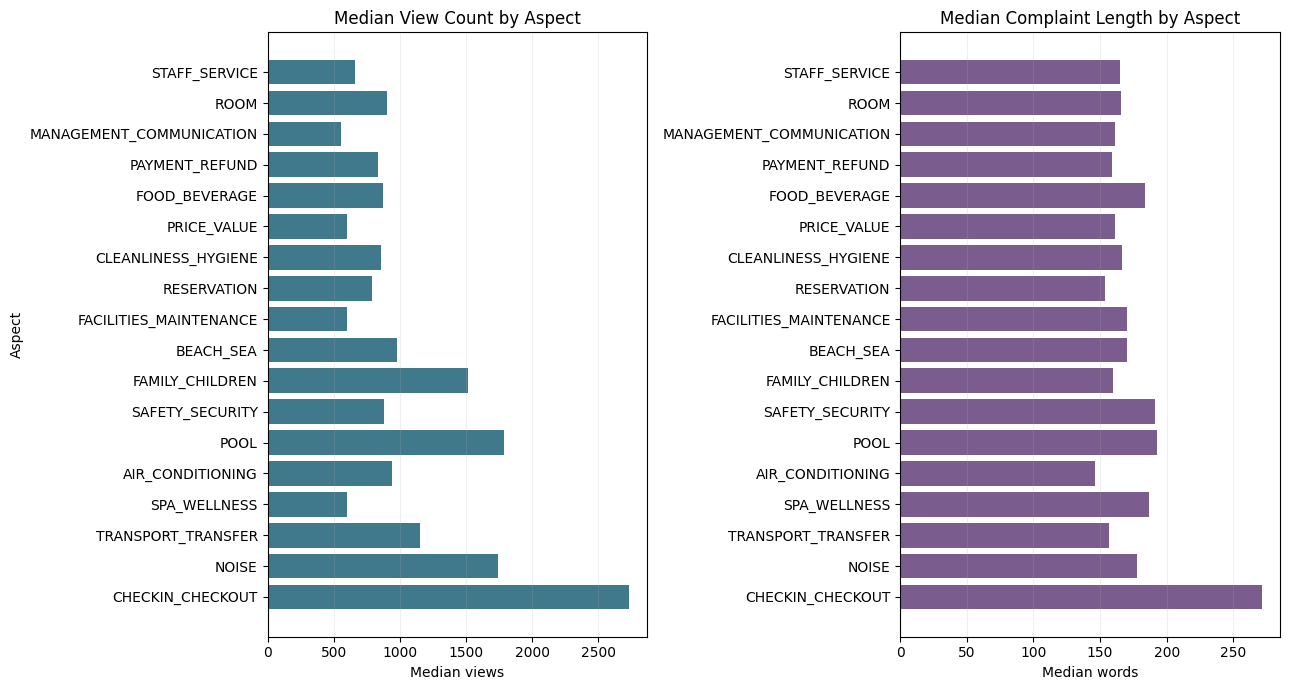

PosixPath('reports/figures/sikayetvar_nlp_aspect/15_aspect_view_and_text_length.png')

In [39]:
plot_context = aspect_frequency.sort_values("complaint_count").copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
axes[0].barh(plot_context["aspect"], plot_context["median_view_count"], color="#40798C")
axes[0].set(title="Median View Count by Aspect", xlabel="Median views", ylabel="Aspect")
axes[1].barh(plot_context["aspect"], plot_context["median_complaint_word_count"], color="#7A5C8E")
axes[1].set(title="Median Complaint Length by Aspect", xlabel="Median words", ylabel="")
for ax in axes: ax.grid(axis="x", alpha=.2)
save_fig(fig, "15_aspect_view_and_text_length.png")


In [40]:
explain_figure(
    "Sol panel aspect geçen complaints'in median platform views; sağ panel median word count değeridir.",
    "Aspect'lerin görünürlük ve anlatım uzunluğu bağlamı aynı sırada karşılaştırılır.",
    "Hangi başlıkların daha uzun anlatıldığını veya daha çok görüntülendiğini descriptive gösterir.",
    "Views yaşla birikir; multi-label complaints panellerde birden fazla aspect'e katkı verir. Causality ve severity yorumu yapılamaz."
)


### Grafik nasıl okunur?
Sol panel aspect geçen complaints'in median platform views; sağ panel median word count değeridir.

### Ne görüyoruz?
Aspect'lerin görünürlük ve anlatım uzunluğu bağlamı aynı sırada karşılaştırılır.

### Neden önemli?
Hangi başlıkların daha uzun anlatıldığını veya daha çok görüntülendiğini descriptive gösterir.

### Dikkat edilmesi gereken nokta
Views yaşla birikir; multi-label complaints panellerde birden fazla aspect'e katkı verir. Causality ve severity yorumu yapılamaz.

## 20. Optional topic modeling gate

In [41]:
topic_gate = pd.DataFrame([
    ("text_document_count", len(valid_documents), "PASS", "229 non-empty complaint texts"),
    ("median_document_tokens", valid_documents["document_token_count"].median(), "PASS", "Narratives are long enough for term/aspect analysis"),
    ("hotel_distribution", readiness["nlp_sample_tier"].eq("LOW_SAMPLE").sum(), "CAUTION", "15/32 hotels are LOW_SAMPLE"),
    ("aspect_coverage_pct", 100*with_aspect_n/text_document_n, "PASS", "Rule-based taxonomy already structures most text documents"),
    ("human_topic_validation", 0, "FAIL", "No independently reviewed topic labels/representatives yet"),
    ("stability_evidence", 0, "FAIL", "No multi-seed coherence/stability benchmark approved"),
], columns=["gate", "value", "status", "note"])
topic_model_status = "TOPIC_MODEL_NOT_RELIABLE"
display(topic_gate)
print(topic_model_status)


,gate,value,status,note
0,text_document_count,229.0,PASS,229 non-empty complaint texts
1,median_document_tokens,112.0,PASS,Narratives are long enough for term/aspect ana...
2,hotel_distribution,15.0,CAUTION,15/32 hotels are LOW_SAMPLE
3,aspect_coverage_pct,100.0,PASS,Rule-based taxonomy already structures most te...
4,human_topic_validation,0.0,FAIL,No independently reviewed topic labels/represe...
5,stability_evidence,0.0,FAIL,No multi-seed coherence/stability benchmark ap...


TOPIC_MODEL_NOT_RELIABLE


NMF/BERTopic/LDA final analize dahil edilmedi. 229 uzun ve çoğunlukla multi-aspect doküman
terim/aspect analizi için yeterli olsa da topic label human validation ve multi-seed stability kanıtı
yoktur. Rule-based taxonomy %95+ coverage sağlarken yeni topic katmanının ek bilgi kazancı henüz
kanıtlanmamıştır. Bu gate metodolojik bir durdurma kararıdır, başarısızlık değildir.


## 21. NLP feature tables

In [42]:
hotel_aspect_wide = hotel_aspect.pivot(
    index=["hotel_id", "hotel_name"], columns="aspect", values="aspect_mention_rate_pct"
).add_prefix("aspect_").add_suffix("_mention_rate_pct").reset_index()
hotel_features = hotel_eda.merge(hotel_aspect_wide, on=["hotel_id", "hotel_name"], how="inner", validate="one_to_one")
hotel_features["nlp_feature_reliability"] = hotel_features["nlp_sample_tier"].str.replace("_SAMPLE", "", regex=False)
hotel_feature_columns = [
    "hotel_id", "hotel_name", "area", "matched_complaint_count",
] + [column for column in hotel_features if column.startswith("aspect_") and column.endswith("_mention_rate_pct")] + [
    "company_response_rate_in_corpus", "median_response_time_days", "median_complaint_word_count",
    "median_view_count", "google_rating", "google_review_count", "official_star_rating_verified",
    "official_room_count", "nlp_sample_tier", "nlp_feature_reliability", "small_n_flag",
]
hotel_features = hotel_features[hotel_feature_columns].rename(columns={"matched_complaint_count":"complaint_n"})
assert hotel_features["hotel_id"].is_unique

area_aspect_wide = area_aspect.pivot(index="area", columns="aspect", values="aspect_mention_rate_pct").add_prefix("aspect_").add_suffix("_mention_rate_pct").reset_index()
area_features = area_eda.merge(area_aspect_wide, on="area", how="left", validate="one_to_one")
area_feature_columns = [
    "area", "project_hotel_count", "mapped_hotel_count", "hotels_with_complaints",
    "matched_complaint_count", "mapping_coverage_pct", "coverage_flag",
] + [column for column in area_features if column.startswith("aspect_") and column.endswith("_mention_rate_pct")] + [
    "company_response_count", "company_response_rate_in_corpus", "median_word_count", "median_view_count",
]
area_features = area_features[area_feature_columns].rename(columns={"matched_complaint_count":"complaint_n"})
assert area_features["area"].is_unique
display(hotel_features.head()); display(area_features)


,hotel_id,hotel_name,area,complaint_n,aspect_AIR_CONDITIONING_mention_rate_pct,aspect_BEACH_SEA_mention_rate_pct,aspect_CHECKIN_CHECKOUT_mention_rate_pct,aspect_CLEANLINESS_HYGIENE_mention_rate_pct,aspect_FACILITIES_MAINTENANCE_mention_rate_pct,aspect_FAMILY_CHILDREN_mention_rate_pct,...,median_response_time_days,median_complaint_word_count,median_view_count,google_rating,google_review_count,official_star_rating_verified,official_room_count,nlp_sample_tier,nlp_feature_reliability,small_n_flag
0,BOD007,Kefaluka Resort,Akyarlar,29,3.448276,24.137931,3.448276,41.379310,41.379310,31.034483,...,0.689583,165.0,921.5,4.4,4293,NaN,NaN,HIGH_SAMPLE,HIGH,False
1,BOD112,Azure By Yelken Hotel,Kadıkalesi,26,3.846154,38.461538,3.846154,61.538462,42.307692,34.615385,...,0.436806,184.5,2076.0,4.4,565,NaN,NaN,HIGH_SAMPLE,HIGH,False
2,BOD115,Yasmin Bodrum Resort,Kadıkalesi,23,13.043478,21.739130,0.000000,39.130435,43.478261,21.739130,...,NaN,107.0,1437.0,4.3,5589,NaN,NaN,HIGH_SAMPLE,HIGH,False
3,BOD106,La Blanche Island Bodrum,Güvercinlik,19,0.000000,47.368421,0.000000,26.315789,31.578947,5.263158,...,0.960417,150.0,922.0,4.3,6594,NaN,NaN,HIGH_SAMPLE,HIGH,False
4,BOD130,Petunya Beach Resort,Ortakent-Yahşi,13,0.000000,15.384615,0.000000,53.846154,15.384615,0.000000,...,NaN,147.0,529.0,3.7,2687,4.0,248.0,MEDIUM_SAMPLE,MEDIUM,False


,area,project_hotel_count,mapped_hotel_count,hotels_with_complaints,complaint_n,mapping_coverage_pct,coverage_flag,aspect_AIR_CONDITIONING_mention_rate_pct,aspect_BEACH_SEA_mention_rate_pct,aspect_CHECKIN_CHECKOUT_mention_rate_pct,...,aspect_RESERVATION_mention_rate_pct,aspect_ROOM_mention_rate_pct,aspect_SAFETY_SECURITY_mention_rate_pct,aspect_SPA_WELLNESS_mention_rate_pct,aspect_STAFF_SERVICE_mention_rate_pct,aspect_TRANSPORT_TRANSFER_mention_rate_pct,company_response_count,company_response_rate_in_corpus,median_word_count,median_view_count
0,Kadıkalesi,4,3,3,56,75.000000,ADEQUATE_EXPLORATORY,10.714286,33.928571,3.571429,...,33.928571,60.714286,25.000000,5.357143,71.428571,8.928571,3,5.357143,141.5,1914.0
1,Akyarlar,16,5,6,55,31.250000,ADEQUATE_EXPLORATORY,3.636364,29.090909,3.636364,...,38.181818,63.636364,21.818182,5.454545,72.727273,1.818182,31,56.363636,159.0,647.5
2,Güvercinlik,10,5,4,39,50.000000,ADEQUATE_EXPLORATORY,2.564103,33.333333,0.000000,...,30.769231,53.846154,20.512821,5.128205,69.230769,5.128205,5,12.820513,151.0,549.0
3,Gümbet,15,6,7,24,40.000000,ADEQUATE_EXPLORATORY,4.166667,29.166667,0.000000,...,54.166667,58.333333,20.833333,0.000000,54.166667,12.500000,0,0.000000,140.0,437.0
4,Ortakent-Yahşi,21,3,3,16,14.285714,LOW,0.000000,18.750000,0.000000,...,56.250000,50.000000,25.000000,6.250000,62.500000,0.000000,0,0.000000,151.5,318.5
5,Bodrum Merkez,13,3,3,13,23.076923,LOW,23.076923,30.769231,0.000000,...,30.769231,69.230769,7.692308,23.076923,84.615385,7.692308,0,0.000000,144.0,352.0
6,Turgutreis,7,2,2,13,28.571429,ADEQUATE_EXPLORATORY,46.153846,46.153846,0.000000,...,23.076923,76.923077,30.769231,7.692308,84.615385,7.692308,0,0.000000,122.0,878.0
7,Torba,21,1,1,10,4.761905,LOW,0.000000,20.000000,0.000000,...,50.000000,60.000000,10.000000,10.000000,30.000000,0.000000,0,0.000000,72.5,3080.5
8,Gümüşlük,15,1,1,7,6.666667,LOW,0.000000,0.000000,0.000000,...,100.000000,57.142857,14.285714,0.000000,14.285714,0.000000,0,0.000000,137.0,31.0
9,Göltürkbükü,10,1,1,2,10.000000,LOW,0.000000,0.000000,0.000000,...,50.000000,0.000000,50.000000,0.000000,100.000000,0.000000,0,0.000000,131.5,210.0


In [43]:
rating_rows = []
eligible_rate_matrix = hotel_aspect[hotel_aspect["hotel_n"].ge(MIN_HOTEL_N)].merge(
    hotel_eda[["hotel_id", "google_rating"]], on="hotel_id", how="left", validate="many_to_one"
)
for aspect, group in eligible_rate_matrix.groupby("aspect"):
    pair = group[["aspect_mention_rate_pct", "google_rating"]].dropna()
    rho, p_value = stats.spearmanr(pair["aspect_mention_rate_pct"], pair["google_rating"]) if len(pair) >= 5 else (np.nan, np.nan)
    rating_rows.append({
        "aspect": aspect, "hotel_n": len(pair), "spearman_rho": rho, "p_value": p_value,
        "main_caution": "Exploratory, unadjusted multiple comparisons; selected hotels with complaint n>=5.",
    })
aspect_rating_correlations = pd.DataFrame(rating_rows).sort_values("spearman_rho")
display(aspect_rating_correlations)

official_context_gate = pd.DataFrame([
    ("official_star_rating_verified", int(hotel_features["official_star_rating_verified"].notna().sum()), len(hotel_features)),
    ("official_room_count", int(hotel_features["official_room_count"].notna().sum()), len(hotel_features)),
], columns=["field", "non_missing_hotels", "complaint_hotel_universe"])
official_context_gate["decision"] = "DESCRIPTIVE_ONLY_LOW_COVERAGE"
display(official_context_gate)


,aspect,hotel_n,spearman_rho,p_value,main_caution
9,PAYMENT_REFUND,17,-0.453270,0.067658,"Exploratory, unadjusted multiple comparisons; ..."
11,PRICE_VALUE,17,-0.448592,0.070902,"Exploratory, unadjusted multiple comparisons; ..."
12,RESERVATION,17,-0.397165,0.114436,"Exploratory, unadjusted multiple comparisons; ..."
15,SPA_WELLNESS,17,-0.203203,0.434083,"Exploratory, unadjusted multiple comparisons; ..."
3,CLEANLINESS_HYGIENE,17,-0.145606,0.577112,"Exploratory, unadjusted multiple comparisons; ..."
7,MANAGEMENT_COMMUNICATION,17,-0.141802,0.587208,"Exploratory, unadjusted multiple comparisons; ..."
1,BEACH_SEA,17,-0.065840,0.801769,"Exploratory, unadjusted multiple comparisons; ..."
13,ROOM,17,0.062618,0.811300,"Exploratory, unadjusted multiple comparisons; ..."
2,CHECKIN_CHECKOUT,17,0.066989,0.798375,"Exploratory, unadjusted multiple comparisons; ..."
17,TRANSPORT_TRANSFER,17,0.125450,0.631406,"Exploratory, unadjusted multiple comparisons; ..."


,field,non_missing_hotels,complaint_hotel_universe,decision
0,official_star_rating_verified,10,32,DESCRIPTIVE_ONLY_LOW_COVERAGE
1,official_room_count,10,32,DESCRIPTIVE_ONLY_LOW_COVERAGE


In [44]:
response_boilerplate = pd.DataFrame(columns=["response_a_complaint_id", "response_b_complaint_id", "cosine_similarity", "candidate_flag"])
response_frame = nlp.loc[nlp["company_response_text_clean"].notna(), ["complaint_id", "company_response_text_clean"]].copy()
if len(response_frame) >= 2:
    response_frame["normalized"] = response_frame["company_response_text_clean"].map(normalize_for_nlp)
    response_vectorizer = TfidfVectorizer(min_df=1, ngram_range=(1, 2), sublinear_tf=True)
    response_matrix = response_vectorizer.fit_transform(response_frame["normalized"])
    similarities = cosine_similarity(response_matrix)
    boilerplate_rows = []
    for i in range(len(response_frame)):
        for j in range(i+1, len(response_frame)):
            if similarities[i, j] >= .80:
                boilerplate_rows.append({
                    "response_a_complaint_id": response_frame.iloc[i]["complaint_id"],
                    "response_b_complaint_id": response_frame.iloc[j]["complaint_id"],
                    "cosine_similarity": similarities[i, j],
                    "candidate_flag": "STANDARDIZED_RESPONSE_PATTERN_CANDIDATE",
                })
    response_boilerplate = pd.DataFrame(boilerplate_rows, columns=response_boilerplate.columns)
display(response_boilerplate.head(20))


,response_a_complaint_id,response_b_complaint_id,cosine_similarity,candidate_flag
0,balayi-konseptinde-sunulan-haklarin-eksikligi-...,kefaluka-resort-balayi-tatilimizde-buyuk-hayal...,1.0,STANDARDIZED_RESPONSE_PATTERN_CANDIDATE


## 22. What we can / cannot say

### Bu NLP analizi ile ne söyleyebiliriz?

- Matched Şikayetvar complaint corpusunda hangi aspect/term/phrase'lerin daha sık geçtiğini.
- Yeterli-sample hotel ve area corpuslarında relative aspect emphasis'i.
- Hangi aspect'lerin aynı complaint içinde birlikte görüldüğünü.
- Hangi aspect'lerde matched company response'un daha sık görüldüğünü.
- Hangi terms'in belirli hotel/area corpuslarını TF-IDF ile ayırt ettiğini.

### Bu NLP analizi ile ne söyleyemeyiz?

- Tüm hotel müşterilerinin ne düşündüğünü veya gerçek problem oranını.
- “Hotel X'in en büyük problemi kesin temizliktir” gibi census iddiasını.
- Daha çok complaint/aspect görülen hotelin daha kötü olduğunu.
- Company response'un problemi çözdüğünü.
- Rule-based keyword eşleşmesinin %100 doğru olduğunu.
- Correlation'ın causation olduğunu veya complaint'i olmayan hotelde aspect rate'in sıfır olduğunu.


## 23. Key findings

In [45]:
top_unigram_text = ", ".join(unigram_domain.head(10)["term"])
top_bigram_text = ", ".join(bigram_table.head(10)["term"])
top_aspect_text = "; ".join(
    f"{row.aspect} %{row.mention_rate_pct:.1f}" for row in aspect_frequency.head(10).itertuples()
)
top_pair_text = "; ".join(
    f"{row.aspect_a}×{row.aspect_b} n={row.cooccurrence_count}" for row in cooccurrence.head(5).itertuples()
)
top_response_text = "; ".join(
    f"{row.aspect} %{row.company_response_rate_within_aspect:.1f} (n={row.complaint_count})"
    for row in eligible_response.sort_values("company_response_rate_within_aspect", ascending=False).head(5).itertuples()
)
key_findings = [
    f"Clean NLP corpus keeps {len(nlp)} rows; {text_document_n} have non-empty complaint_text_clean across {nlp.hotel_id.nunique()} hotels and {nlp.area.nunique()} represented areas.",
    f"Standard preprocessing yields {len(all_tokens)} tokens and {len(set(all_tokens))} unique surface tokens; median document length is {valid_documents.document_token_count.median():.0f} tokens.",
    f"Top domain-filtered unigrams: {top_unigram_text}.",
    f"Top supported bigrams: {top_bigram_text}.",
    f"Final explainable taxonomy contains {len(CANONICAL_ASPECTS)} multi-label aspects; no overall sentiment model was run.",
    f"At least one aspect is detected in {with_aspect_n}/{len(nlp)} clean rows ({100*with_aspect_n/len(nlp):.1f}%); no-aspect n={no_aspect_n}.",
    f"Mean/median aspects per clean complaint are {nlp.aspect_count.mean():.2f}/{nlp.aspect_count.median():.0f}; totals exceed document n because detection is multi-label.",
    f"Top aspect mention rates: {top_aspect_text}.",
    f"Strongest supported co-occurrences: {top_pair_text}.",
    f"Major-aspect company response shares: {top_response_text}; response is not resolution.",
    f"Response-time analysis includes {len(response_time_plot)} aspects with response-date n>={MIN_ASPECT_RESPONSE_N}; approximate dates limit precision.",
    f"Hotel aspect heatmap includes {hotel_heatmap.shape[0]} HIGH/MEDIUM-sample hotels; LOW_SAMPLE hotels remain in CSV with caution flags.",
    f"Area heatmap includes {area_heatmap.shape[0]} areas with n>={MIN_AREA_N}; mapping coverage is unequal.",
    f"TF-IDF distinctive terms are produced for {distinctive_hotel.hotel_name.nunique()} hotels and {distinctive_area.area.nunique()} areas, as relative corpus markers rather than definitive problems.",
    f"Google-rating × aspect correlations are exploratory across {int(eligible_rate_matrix.hotel_id.nunique())} eligible hotels and are not multiple-comparison adjusted.",
    f"Official room coverage is {int(hotel_features.official_room_count.notna().sum())}/{len(hotel_features)} complaint hotels, so size/star aspect context is descriptive only.",
    f"Topic status is {topic_model_status}: independent human labels and multi-seed stability evidence are not yet available.",
    "Segmentation-ready features include aspect mention rates, response behavior, text/view medians, sample reliability, Google context and explicit coverage indicators.",
]
for finding in key_findings:
    print("-", finding)


- Clean NLP corpus keeps 236 rows; 229 have non-empty complaint_text_clean across 32 hotels and 11 represented areas.
- Standard preprocessing yields 28690 tokens and 8259 unique surface tokens; median document length is 112 tokens.
- Top domain-filtered unigrams: hiçbir, oda, rezervasyon, odada, yok, giriş, saat, aynı, derece, hizmet.
- Top supported bigrams: hayal kırıklığı, iade edilmesini, ücret iadesi, ultra dahil, geri dönüş, giriş yaptık, hayal kırıklığına, çözüm sunulmadı, kabul edilemez, tarafıma iade.
- Final explainable taxonomy contains 18 multi-label aspects; no overall sentiment model was run.
- At least one aspect is detected in 229/236 clean rows (97.0%); no-aspect n=7.
- Mean/median aspects per clean complaint are 5.80/6; totals exceed document n because detection is multi-label.
- Top aspect mention rates: STAFF_SERVICE %67.4; ROOM %60.2; MANAGEMENT_COMMUNICATION %59.3; PAYMENT_REFUND %52.1; FOOD_BEVERAGE %51.7; PRICE_VALUE %47.9; CLEANLINESS_HYGIENE %44.9; RESERVATIO

## 24. Limitations

In [46]:
limitations = [
    "Şikayetvar is a self-selected complaint platform; only reliably matched complaints are analyzed.",
    "Mapping coverage is unequal across hotels and areas; complaint absence must not be encoded as zero aspect risk.",
    "The complaint-hotel sample is 32 hotels and 15 are LOW_SAMPLE, so hotel-level rates are unstable.",
    "Rule-based dictionaries have false-positive and false-negative risk; manual validation remains TO_REVIEW.",
    "Turkish morphology and surface-form variation are only conservatively handled without a validated lemmatizer.",
    "Multi-label aspect overlap means aspect counts and rates do not sum to complaint count or 100%.",
    "Broad/ambiguous words such as service, room, entry, card and sound require context review.",
    "Company response existence, speed or template similarity does not establish resolution or satisfaction.",
    "Google and Şikayetvar represent different populations and time windows.",
    "Official star/capacity coverage is incomplete; capacity-related aspect comparisons are not robust.",
    "Topic modeling on a small selected corpus risks unstable and forced labels; it was gated out.",
    "Historical/platform completeness is uncertain and 86 complaint dates are approximate.",
    "TF-IDF is relative distinctiveness, not proof of a hotel's definitive problem.",
    "All rating/aspect correlations are exploratory, unadjusted for multiple comparisons and non-causal.",
]
for item in limitations:
    print("-", item)


- Şikayetvar is a self-selected complaint platform; only reliably matched complaints are analyzed.
- Mapping coverage is unequal across hotels and areas; complaint absence must not be encoded as zero aspect risk.
- The complaint-hotel sample is 32 hotels and 15 are LOW_SAMPLE, so hotel-level rates are unstable.
- Rule-based dictionaries have false-positive and false-negative risk; manual validation remains TO_REVIEW.
- Turkish morphology and surface-form variation are only conservatively handled without a validated lemmatizer.
- Multi-label aspect overlap means aspect counts and rates do not sum to complaint count or 100%.
- Broad/ambiguous words such as service, room, entry, card and sound require context review.
- Company response existence, speed or template similarity does not establish resolution or satisfaction.
- Google and Şikayetvar represent different populations and time windows.
- Official star/capacity coverage is incomplete; capacity-related aspect comparisons are not rob

## 25. Next step, exports and validation

In [47]:
report_paths = {
    "corpus_summary": REPORTS_DIR / "sikayetvar_nlp_corpus_summary.csv",
    "unigrams": REPORTS_DIR / "sikayetvar_nlp_unigram_frequency.csv",
    "ngrams": REPORTS_DIR / "sikayetvar_nlp_ngrams.csv",
    "distinctive_hotel": REPORTS_DIR / "sikayetvar_nlp_distinctive_terms_by_hotel.csv",
    "distinctive_area": REPORTS_DIR / "sikayetvar_nlp_distinctive_terms_by_area.csv",
    "dictionary": REPORTS_DIR / "sikayetvar_aspect_dictionary.csv",
    "coverage": REPORTS_DIR / "sikayetvar_aspect_coverage_summary.csv",
    "frequency": REPORTS_DIR / "sikayetvar_aspect_frequency.csv",
    "hotel_matrix": REPORTS_DIR / "sikayetvar_hotel_aspect_matrix.csv",
    "area_matrix": REPORTS_DIR / "sikayetvar_area_aspect_matrix.csv",
    "hotel_lift": REPORTS_DIR / "sikayetvar_hotel_aspect_lift.csv",
    "area_lift": REPORTS_DIR / "sikayetvar_area_aspect_lift.csv",
    "cooccurrence": REPORTS_DIR / "sikayetvar_aspect_cooccurrence.csv",
    "response": REPORTS_DIR / "sikayetvar_aspect_response_summary.csv",
    "manual_sample": REPORTS_DIR / "sikayetvar_aspect_manual_validation_sample.csv",
    "kwic": REPORTS_DIR / "sikayetvar_aspect_keyword_context_samples.csv",
    "collisions": REPORTS_DIR / "sikayetvar_aspect_keyword_collisions.csv",
    "hotel_top": REPORTS_DIR / "sikayetvar_hotel_top_aspects.csv",
    "area_top": REPORTS_DIR / "sikayetvar_area_top_aspects.csv",
    "rating_corr": REPORTS_DIR / "sikayetvar_aspect_google_rating_correlations.csv",
    "topic_gate": REPORTS_DIR / "sikayetvar_topic_model_gate.csv",
    "temporal": REPORTS_DIR / "sikayetvar_temporal_aspect_summary.csv",
    "response_terms": REPORTS_DIR / "sikayetvar_company_response_terms.csv",
    "boilerplate": REPORTS_DIR / "sikayetvar_company_response_boilerplate.csv",
    "key_findings": REPORTS_DIR / "sikayetvar_nlp_key_findings.txt",
    "limitations": REPORTS_DIR / "sikayetvar_nlp_limitations.txt",
}
processed_paths = {
    "complaints_nlp": PROCESSED_DIR / "sikayetvar_all_hotels_complaints_nlp.csv",
    "aspects_long": PROCESSED_DIR / "sikayetvar_complaint_aspects_long.csv",
    "hotel_features": PROCESSED_DIR / "sikayetvar_hotel_nlp_features.csv",
    "area_features": PROCESSED_DIR / "sikayetvar_area_nlp_features.csv",
    "readme": PROCESSED_DIR / "README_sikayetvar_nlp_features.txt",
}

corpus_summary.to_csv(report_paths["corpus_summary"], index=False)
unigram_standard.to_csv(report_paths["unigrams"], index=False)
ngram_table.to_csv(report_paths["ngrams"], index=False)
distinctive_hotel.to_csv(report_paths["distinctive_hotel"], index=False)
distinctive_area.to_csv(report_paths["distinctive_area"], index=False)
aspect_dictionary.to_csv(report_paths["dictionary"], index=False)
aspect_coverage.to_csv(report_paths["coverage"], index=False)
aspect_frequency.to_csv(report_paths["frequency"], index=False)
hotel_aspect.to_csv(report_paths["hotel_matrix"], index=False)
area_aspect.to_csv(report_paths["area_matrix"], index=False)
hotel_lift.to_csv(report_paths["hotel_lift"], index=False)
area_lift.to_csv(report_paths["area_lift"], index=False)
cooccurrence.to_csv(report_paths["cooccurrence"], index=False)
aspect_response_summary.to_csv(report_paths["response"], index=False)
manual_validation_sample.to_csv(report_paths["manual_sample"], index=False)
keyword_context_samples.to_csv(report_paths["kwic"], index=False)
keyword_collisions.to_csv(report_paths["collisions"], index=False)
hotel_top_aspects.to_csv(report_paths["hotel_top"], index=False)
area_top_aspects.to_csv(report_paths["area_top"], index=False)
aspect_rating_correlations.to_csv(report_paths["rating_corr"], index=False)
topic_gate.to_csv(report_paths["topic_gate"], index=False)
temporal_aspect_summary.to_csv(report_paths["temporal"], index=False)
response_terms.to_csv(report_paths["response_terms"], index=False)
response_boilerplate.to_csv(report_paths["boilerplate"], index=False)
report_paths["key_findings"].write_text("\n".join(f"- {item}" for item in key_findings) + "\n", encoding="utf-8")
report_paths["limitations"].write_text("\n".join(f"- {item}" for item in limitations) + "\n", encoding="utf-8")

nlp_export = nlp.copy()
nlp_export["nlp_tokens"] = nlp_export["nlp_tokens"].map(lambda values: "|".join(values))
nlp_export["nlp_tokens_domain_filtered"] = nlp_export["nlp_tokens_domain_filtered"].map(lambda values: "|".join(values))
nlp_export.to_csv(processed_paths["complaints_nlp"], index=False)
aspects_long.to_csv(processed_paths["aspects_long"], index=False)
hotel_features.to_csv(processed_paths["hotel_features"], index=False)
area_features.to_csv(processed_paths["area_features"], index=False)

feature_readme = (
    "ŞİKAYETVAR NLP FEATURES\n\n"
    f"Corpus definition: Notebook 12 canonical-unique reliably matched clean complaints; {len(nlp)} rows, {text_document_n} non-empty texts.\n"
    "Preprocessing: NFKC, Turkish lowercase, whitespace/punctuation cleanup, URL/email/phone masking in derived NLP text; raw text unchanged.\n"
    f"Taxonomy: {len(CANONICAL_ASPECTS)} explainable multi-label aspects; phrase-first, word-boundary and limited Turkish surface-form rules.\n"
    "Mention rate: unique complaints matching aspect / group clean complaint count * 100. It is not a real customer problem rate.\n"
    "Hotel aggregation: one row per 32 complaint-bearing hotels; sample reliability uses Notebook 13 HIGH/MEDIUM/LOW tiers.\n"
    "Area aggregation: all 14 project areas retained; areas without clean complaint data have missing aspect rates, not zero.\n"
    "Small-n handling: hotel n<5 and area n<10 excluded from main heatmaps but retained with flags.\n"
    "Company response: existence/rate/time are operational descriptors and do not imply resolution.\n"
    "Missing coverage policy: hotels without trusted complaint data must not receive aspect rate=0; use data-availability and mapping-status indicators downstream.\n"
    "Limitations: self-selected platform, unequal mapping coverage, Turkish morphology, rule-based errors, multi-label overlap, incomplete official metadata, non-causal correlations.\n"
    "Intended use: coverage-aware segmentation/opportunity features with reliability indicators; not hotel quality scoring.\n"
)
processed_paths["readme"].write_text(feature_readme, encoding="utf-8")

input_hashes_after = {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in protected_inputs}
figure_paths = sorted(FIGURES_DIR.glob("*.png"))
output_validation = pd.DataFrame([
    ("clean_inputs_unchanged", input_hashes_before == input_hashes_after),
    ("nlp_row_count_preserved", len(nlp_export) == len(complaints)),
    ("complaint_id_unique", nlp_export["complaint_id"].is_unique),
    ("aspect_columns_boolean", all(nlp[column].dtype == bool for column in aspect_columns)),
    ("aspect_count_reconciles", (nlp[aspect_columns].sum(axis=1) == nlp["aspect_count"]).all()),
    ("long_relation_reconciles", len(aspects_long) == len(nlp)*len(CANONICAL_ASPECTS) and int(aspects_long["matched"].sum()) == int(nlp["aspect_count"].sum())),
    ("no_aspect_reconciles", int(nlp["no_aspect_detected_flag"].sum()) == int(nlp["aspect_count"].eq(0).sum())),
    ("hotel_rates_valid", hotel_aspect["aspect_mention_rate_pct"].between(0, 100).all()),
    ("area_rates_valid", area_aspect["aspect_mention_rate_pct"].between(0, 100).all()),
    ("response_rates_valid", aspect_response_summary["company_response_rate_within_aspect"].dropna().between(0, 100).all()),
    ("hotel_feature_keys_unique", hotel_features["hotel_id"].is_unique),
    ("area_feature_keys_unique", area_features["area"].is_unique),
    ("small_n_rule_correct", (hotel_aspect["small_n_flag"] == hotel_aspect["hotel_n"].lt(MIN_HOTEL_N)).all()),
    ("manual_validation_sample_30_50", 30 <= len(manual_validation_sample) <= 50),
    ("topic_gate_respected", topic_model_status == "TOPIC_MODEL_NOT_RELIABLE"),
    ("all_15_figures_present", len(figure_paths) == 15),
    ("all_reports_present", all(path.exists() for path in report_paths.values())),
    ("all_processed_outputs_present", all(path.exists() for path in processed_paths.values())),
], columns=["check", "passed"])
output_validation.to_csv(REPORTS_DIR / "sikayetvar_nlp_output_validation.csv", index=False)
assert output_validation["passed"].all(), output_validation.loc[~output_validation["passed"]].to_dict("records")
display(output_validation)
print(f"Validated {len(figure_paths)} figures, {len(report_paths)} reports and {len(processed_paths)} processed outputs.")


,check,passed
0,clean_inputs_unchanged,True
1,nlp_row_count_preserved,True
2,complaint_id_unique,True
3,aspect_columns_boolean,True
4,aspect_count_reconciles,True
5,long_relation_reconciles,True
6,no_aspect_reconciles,True
7,hotel_rates_valid,True
8,area_rates_valid,True
9,response_rates_valid,True


Validated 15 figures, 26 reports and 5 processed outputs.


### Sonraki aşama

Önerilen notebook: `notebooks/15_hotel_segmentation.ipynb`. Segmentation; hotel master,
destination context, official attributes ve yalnız coverage/reliability göstergeleriyle birlikte
NLP features kullanmalıdır. Complaint bulunmayan project hotel'lerde aspect rate **0 yapılmamalı**;
`sikayetvar_data_available` ve `sikayetvar_mapping_status` ayrı feature olarak taşınmalıdır.

**Hazırlık kararı:** Aspect/response/text features segmentation için hazırdır; LOW_SAMPLE hotel
rate'leri shrink/pool edilmeli veya ana clustering girdisi dışında sensitivity katmanında tutulmalıdır.
